# GHZ states and decoherence — genuine multipartite entanglement and its fragility

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 8 — Quantum information protocols*

## 1. Introduction and motivation

The state

$$\vert\mathrm{GHZ}_N\rangle=\frac{\vert00\cdots0\rangle+\vert11\cdots1\rangle}{\sqrt2}$$

is the simplest thing one can write down that is *genuinely* $N$-partite entangled, and it is simultaneously the most fragile.
Every qubit is perfectly correlated with every other one, yet no pair of qubits shares any entanglement at all; the whole
resource lives in a single coherence between two basis states that are as far apart as two basis states can be. That is what
makes it a standard benchmark of quantum platforms: preparing $\vert\mathrm{GHZ}_N\rangle$ and *proving* that you have it
tests the coherence of the whole register at once. Ion traps reached $N=4$ (Sackett and co-workers, 2000), $N=6$ (Leibfried and
co-workers, 2005) and $N=14$ (Monz and co-workers, 2011); superconducting and neutral-atom processors have since pushed further.
The ion-trap experiments characterise the state through the quantities we compute here: the two extreme **populations**, the
**parity oscillation** that measures the coherence between them, and the **fidelity** built from the two.

The state also has a place in the foundations of quantum mechanics. Greenberger, Horne and Zeilinger showed in 1989, for four
spin-$\tfrac12$ particles, that the conflict with local realism becomes an *all-or-nothing* contradiction, and Mermin (*Physics Today*, 1990)
reduced the argument to three: where CHSH is a statistical inequality, here a single sign is predicted wrongly with certainty
by every local-realistic model. We derive that contradiction
from the stabilisers in Section 5; it takes three lines once the algebra is set up.

And it is the workhorse of quantum metrology: the phase accumulated by $\vert\mathrm{GHZ}_N\rangle$ is $N$ times faster than that
of a single qubit, which is the origin of the Heisenberg limit (Chapter 10). The very same $N$-fold enhancement makes it decay
$N$ times faster under dephasing. The tension between those two statements — *the best sensor is the most fragile state* — is the
subject of the second half of this notebook.

**Road map.**

1. Define the state, prepare it two ways — the textbook $H$ + $\mathrm{CNOT}$ cascade of depth $N-1$, and a **log-depth tree** of
   depth $\lceil\log_2N\rceil$ — and check that they agree (Sections 3–4).
2. Certify it: the $N$ **stabiliser generators** $Z_qZ_{q+1}$ and $X^{\otimes N}$, all pairwise correlators, and the
   Greenberger–Horne–Zeilinger sign (Section 5).
3. Show the paradox: every pair has $\langle Z_iZ_j\rangle=1$, and yet **every two-qubit reduced state is a separable classical
   mixture**; tracing out a single qubit leaves a state with zero entanglement across every cut (Sections 6–7).
4. Measure the $N$-body coherence the way experiments do: **parity oscillations** $\langle X^{\otimes N}\rangle(\varphi)=\cos(N\varphi)$
   after a collective $R_z(\varphi)$, and combine them with populations into the **fidelity witness** $F>1/2$ (Sections 8–9).
5. Decoherence. Derive closed formulas for the coherence, for $\langle Z_1Z_2\rangle$ and for the fidelity under local dephasing,
   depolarising and amplitude damping; verify them on the exact density tensor for $N\le6$; then unravel the same channels into
   **quantum trajectories**, check the $1/\sqrt M$ convergence with error bars, and use them to reach $N=12$, where a density
   tensor would need $2^{24}$ complex numbers (Sections 10–14).
6. Quantify the **fragility**: the noise level at which the witness stops working shrinks roughly like $1/N$ (Section 15).
7. Compare with the **W state**, which is entangled in a completely different way: part of its entanglement survives the loss
   of a qubit, while that of GHZ is destroyed completely (Section 16).

### What you will learn

*Physics*

* what "genuinely $N$-partite" entanglement means, and why $\langle Z_iZ_j\rangle=1$ for all pairs carries no evidence of it;
* stabiliser formalism in its smallest useful instance: $N$ commuting operators that determine a state uniquely;
* $N$-body coherence, parity oscillations, and why their frequency is the resource that metrology exploits;
* entanglement witnesses: a *sufficient* certificate that is cheap to measure, and what it does and does not prove;
* how the three standard single-qubit channels attack a GHZ state, and why the damage grows with $N$;
* the two inequivalent classes of tripartite entanglement (GHZ and W) and their opposite behaviour under particle loss.

*Numerical methods*

* exact open-system dynamics on a density tensor ($O(4^N)$) versus Monte-Carlo wave-function trajectories ($O(2^N)$ per
  trajectory), and when each is the right tool;
* which observables can be estimated from trajectories (linear ones) and which cannot (negativity, entropies);
* statistical error bars, $1/\sqrt M$ convergence, and how to check a stochastic estimator against an exact reference;
* bisection for a threshold, and fitting a power law on a log-log plot.

*Implementation practice*

* `vmap` over trajectories and over parameter grids; one compiled program, thousands of independent stochastic runs;
* a circuit as a Python loop of einsums, and how the loop structure encodes circuit *depth*;
* building a channel from Kraus operators and applying it to a density tensor with a single einsum over the Kraus index;
* the discipline of deriving a formula first and only then measuring it — every analytic result below is checked against the
  simulator, and every simulated number against the formula.

### Prerequisites
* [01 — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, PRNG keys;
* [02 — einsum from scratch](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb);
* [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb): reduced density
  matrices, entanglement entropy;
* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb):
  density tensors, Kraus operators, fidelity;
* [09 — quantum gates and circuits](../ch04_digital_quantum_circuits/09_quantum_gates_and_circuits.ipynb): $H$, $\mathrm{CNOT}$,
  circuit depth;
* [17 — Monte-Carlo wave function](../ch06_open_quantum_systems/17_monte_carlo_wave_function.ipynb): the trajectory unravelling
  we use from Section 13 on;
* helpful: [19 — Bell states and CHSH](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb) for the two-qubit
  version of everything here.

**Conventions.** Qubit $q$ = tensor axis $q$, counted from $0$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$; Pauli strings are
written with qubit $0$ leftmost. We abbreviate $\vert\bar0\rangle=\vert0\cdots0\rangle$ and $\vert\bar1\rangle=\vert1\cdots1\rangle$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and helpers

We use the einsum primitives for state vectors and density tensors, the standard Kraus channels, the trajectory sampler
`apply_kraus_mcwf`, and the negativity. Everything specific to GHZ states is written from scratch below.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def dicke_state(N, k):
    """Symmetric Dicke state |D_N^k>: equal superposition of all basis states with exactly k ones.
    Implementation: mask of the flat indices with popcount == k, normalised by sqrt(binom(N,k))."""
    idx = np.arange(2 ** N)
    pop = np.array([bin(i).count("1") for i in idx])
    v = (pop == k).astype(np.complex128)
    return jnp.asarray(v / np.linalg.norm(v), dtype=CDTYPE).reshape((2,) * N)

def w_state(N):
    """W state = Dicke state with one excitation: (|10..0> + |01..0> + ... + |0..01>)/sqrt(N)."""
    return dicke_state(N, 1)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))

def expect_pauli_string_dm(rho, ops):
    """Tr(P rho): apply P to the KET axes only, then take the full trace."""
    return jnp.real(jnp.trace(dm_matrix(apply_pauli_string(rho, ops))))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def von_neumann_entropy(rho_mat, base=2.0):
    """S(rho) = -Tr(rho log rho) = -sum_i lambda_i log lambda_i  (in bits for base=2).
    Eigenvalues are clipped at 1e-16 because 0*log(0) := 0 but log(0) = -inf numerically."""
    lam = jnp.clip(jnp.linalg.eigvalsh(rho_mat), 1e-16, None)
    return -jnp.sum(lam * jnp.log(lam)) / jnp.log(base)

def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def _sqrtm_psd(A):
    """Square root of a positive semi-definite matrix via eigendecomposition: V sqrt(w) V^dag."""
    w, v = jnp.linalg.eigh(A)
    return (v * jnp.sqrt(jnp.clip(w, 0, None))) @ v.conj().T

def as_dm_tensor(rho):
    """Accept a density matrix in EITHER form and return the rank-2N tensor (2,)*2N.

    Both conventions are in use: `rdm` and `dm_matrix` return a (2^N, 2^N) MATRIX, while
    `to_dm` and the channel functions work with the rank-2N TENSOR (N ket axes, then N bra axes).
    A (2^N, 2^N) matrix with N > 1 is unambiguous, because a density tensor has every axis of length 2.
    Passing the matrix form straight to `partial_transpose` used to transpose the WHOLE matrix, which
    leaves the eigenvalues alone and silently reports zero negativity -- hence this conversion.
    """
    rho = jnp.asarray(rho)
    if rho.ndim == 2 and rho.shape[0] > 2:                  # (2^N, 2^N) matrix with N > 1
        d = rho.shape[0]
        N = int(round(math.log2(d)))
        if 2 ** N != d:
            raise ValueError(f"density matrix of dimension {d} is not a power of two")
        return rho.reshape((2,) * (2 * N))
    if any(s != 2 for s in rho.shape) or rho.ndim % 2:
        raise ValueError(f"not a density matrix or density tensor: shape {rho.shape}")
    return rho

def partial_transpose(rho, qubits):
    """Partial transpose on subsystem A = `qubits`, for a density tensor OR a (2^N, 2^N) matrix.
    In tensor form it is trivial: SWAP the ket axis q with the bra axis N+q for q in A.
    (With a 2^N x 2^N matrix this requires painful index gymnastics -- here: one `transpose`.)
    RETURNS the rank-2N tensor; wrap in `dm_matrix` for the matrix form."""
    rho = as_dm_tensor(rho)
    N = rho.ndim // 2
    perm = list(range(2 * N))
    for q in qubits:
        perm[q], perm[N + q] = perm[N + q], perm[q]
    return jnp.transpose(rho, perm)

def negativity(rho, qubits):
    """Entanglement negativity (Peres-Horodecki / PPT criterion).
        N(rho) = (||rho^{T_A}||_1 - 1)/2 = sum of |negative eigenvalues| of the partial transpose,
        E_N    = log2 ||rho^{T_A}||_1 = log2(2N+1)      (logarithmic negativity).
    N > 0  =>  entangled (for 2x2 and 2x3 systems also <=).   Returns (N, E_N)."""
    lam = jnp.linalg.eigvalsh(dm_matrix(partial_transpose(rho, qubits)))
    neg = jnp.sum(jnp.abs(lam) - lam) / 2
    return neg, jnp.log2(2 * neg + 1)


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) sigma^-)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])

def apply_kraus_mcwf(key, psi, kraus, qubits):
    """Apply a channel to a PURE state stochastically (quantum trajectory / Monte-Carlo wave function).

    MATH   choose branch m with probability  p_m = ||K_m psi||^2 = Tr(K_m rho_A K_m^dag)
           then  |psi> -> K_m|psi> / sqrt(p_m).
           Averaging |psi><psi| over many trajectories gives exactly  sum_m K_m rho K_m^dag.
    WHY    memory O(2^N) instead of O(4^N): open systems at the price of closed ones (times #trajectories,
           which are embarrassingly parallel -> jax.vmap over keys).
    IMPLEMENTATION   probabilities come from the SMALL reduced density matrix (einsum "mab,bc,mac->m");
           `K[m]` with a traced integer m is a gather, so everything stays jit-compatible.
    """
    K = jnp.asarray(kraus, dtype=CDTYPE)
    r = rdm(psi, qubits)
    probs = jnp.real(jnp.einsum("mab,bc,mac->m", K, r, jnp.conj(K)))
    m = jax.random.categorical(key, jnp.log(jnp.clip(probs, 1e-300, None)))
    psi = apply_gate(psi, K[m], qubits)
    return psi / jnp.linalg.norm(psi)


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
import itertools

PALETTE =["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def dm_tensor(mat, N):
    """Inverse of `dm_matrix`: view a 2^N x 2^N matrix as a rank-2N density tensor (ket axes 0..N-1, bra axes N..2N-1)."""
    return jnp.asarray(mat, dtype=CDTYPE).reshape((2,) * (2 * N))


def concurrence(rho_mat):
    """Wootters' concurrence of a TWO-qubit density matrix (Phys. Rev. Lett. 80, 2245 (1998)).

    MATH   rho~ = (Y (x) Y) rho^* (Y (x) Y);  lambda_i = sqrt(eigenvalues of rho rho~), sorted decreasingly;
           C = max(0, lambda_1 - lambda_2 - lambda_3 - lambda_4).   C = 0 separable, C = 1 maximally entangled.
    IMPLEMENTATION  use the Hermitian, similar matrix sqrt(rho) rho~ sqrt(rho) so that `eigvalsh` applies.
    """
    YY_ = jnp.kron(Y, Y)
    rho_mat = jnp.asarray(rho_mat, dtype=CDTYPE)
    s = _sqrtm_psd(rho_mat)
    lam = jnp.sqrt(jnp.clip(jnp.linalg.eigvalsh(s @ (YY_ @ jnp.conj(rho_mat) @ YY_) @ s), 0.0, None))
    return float(jnp.maximum(0.0, lam[3] - lam[2] - lam[1] - lam[0]))


def neg_cut(rho_tensor, cut):
    """Negativity of a density TENSOR across the bipartition (`cut` | rest)."""
    return float(negativity(rho_tensor, list(cut))[0])

## 3. The state and its bipartite entanglement

### 3.1 Definition

For $N$ qubits,

$$\vert\mathrm{GHZ}_N\rangle=\frac{1}{\sqrt2}\big(\vert\bar0\rangle+\vert\bar1\rangle\big),\qquad
  \vert\bar0\rangle=\vert0\rangle^{\otimes N},\quad\vert\bar1\rangle=\vert1\rangle^{\otimes N}.$$

As a rank-$N$ tensor of shape $(2,\dots,2)$ it has exactly **two** non-zero entries out of $2^N$, both equal to $1/\sqrt2$:
`psi[0,0,...,0] = psi[1,1,...,1] = 1/sqrt(2)`. Two numbers specify it completely; Sections 10–15 show how quickly local noise destroys it.

### 3.2 Schmidt decomposition across an arbitrary cut

For $N=2$ it *is* a Bell state, $\vert\Phi^+\rangle$. For $N\ge3$ something new happens. Split the qubits into any two groups
$A$ and $B$; the Schmidt decomposition across that cut reads

$$\vert\mathrm{GHZ}_N\rangle=\frac{1}{\sqrt2}\vert\bar0\rangle_A\vert\bar0\rangle_B+\frac{1}{\sqrt2}\vert\bar1\rangle_A\vert\bar1\rangle_B,$$

with Schmidt coefficients $(1/\sqrt2,1/\sqrt2)$ — so **every** bipartition carries exactly $1$ bit of entanglement entropy, no
matter how the qubits are split. That is already unusual: a random state of $N$ qubits has entropy close to $\min(\vert A\vert,\vert B\vert)$
bits. Across a single-qubit cut one bit is the maximum possible, so the GHZ state is *maximally* entangled there; across a
balanced cut of $N=10$ qubits the maximum is five bits and the GHZ state still delivers only one, the most that Schmidt rank
$2$ allows. The same number is maximal at one end and small at the other, the first hint that the entanglement of this state
is a property of the whole register and cannot be described cut by cut.

The next cell builds the state and checks this.

In [4]:
# ==============================================================================
# STEP 1: the GHZ tensor and the entanglement entropy of every bipartition
# ==============================================================================
N_DEMO = 5
ghz5 = ghz_state(N_DEMO)
nz = np.argwhere(np.abs(np.asarray(ghz5)) > 1e-12)
print(f"GHZ_{N_DEMO} has {nz.shape[0]} non-zero amplitudes out of 2^{N_DEMO} = {2 ** N_DEMO}:")
for idx in nz:
    print(f"   psi[{','.join(map(str, idx))}] = {complex(ghz5[tuple(idx)]).real:.6f}")

print(f"\n{'subsystem A':>22s} {'S_A [bits]':>12s}")
errS = 0.0
for k in range(1, N_DEMO):
    for A in itertools.combinations(range(N_DEMO), k):
        S = float(entanglement_entropy(ghz5, A))
        errS = max(errS, abs(S - 1.0))
        if k <= 2 or A == tuple(range(k)):
            print(f"{str(A):>22s} {S:12.9f}")
print(f"\nlargest deviation of S_A from 1 bit over ALL {2 ** N_DEMO - 2} bipartitions: {errS:.2e}")
assert errS < 1e-9

GHZ_5 has 2 non-zero amplitudes out of 2^5 = 32:
   psi[0,0,0,0,0] = 0.707107
   psi[1,1,1,1,1] = 0.707107

           subsystem A   S_A [bits]


                  (0,)  1.000000000
                  (1,)  1.000000000
                  (2,)  1.000000000
                  (3,)  1.000000000
                  (4,)  1.000000000
                (0, 1)  1.000000000


                (0, 2)  1.000000000
                (0, 3)  1.000000000
                (0, 4)  1.000000000
                (1, 2)  1.000000000
                (1, 3)  1.000000000
                (1, 4)  1.000000000
                (2, 3)  1.000000000
                (2, 4)  1.000000000
                (3, 4)  1.000000000
             (0, 1, 2)  1.000000000


          (0, 1, 2, 3)  1.000000000

largest deviation of S_A from 1 bit over ALL 30 bipartitions: 1.07e-14


Two non-zero amplitudes, and every one of the $2^5-2=30$ bipartitions carries exactly one bit of entanglement entropy. The state
is "flat": it does not care how you cut it.

> **Physics insight.** One bit per cut sounds modest, and for a *bipartite* purpose it is. What is special is that the same one
> bit is shared by *all* the qubits at once and cannot be attributed to any subset — which is exactly what Sections 6 and 7 will
> make quantitative.

## 4. Two ways to prepare it: the cascade and the tree

### 4.1 The textbook cascade

Start from $\vert\bar0\rangle$, put qubit $0$ into $\vert+\rangle$ with a Hadamard, and then copy that bit along the chain with
$\mathrm{CNOT}$s:

$$\vert0\cdots0\rangle\;\xrightarrow{\;H_0\;}\;\frac{\vert0\rangle+\vert1\rangle}{\sqrt2}\vert0\cdots0\rangle
 \;\xrightarrow{\;\mathrm{CNOT}_{0\to1}\;}\;\frac{\vert00\rangle+\vert11\rangle}{\sqrt2}\vert0\cdots0\rangle
 \;\xrightarrow{\;\mathrm{CNOT}_{1\to2}\;}\;\cdots$$

Each $\mathrm{CNOT}$ extends the correlated block by one qubit, because $\mathrm{CNOT}$ acting on $\vert x\rangle\vert0\rangle$
gives $\vert x\rangle\vert x\rangle$ and the map is linear, so the two branches of the superposition are copied independently.
(The no-cloning theorem is respected: the $\mathrm{CNOT}$ copies the basis states $\vert0\rangle$ and $\vert1\rangle$, and no
unknown superposition is duplicated; see the no-cloning discussion in
[20 — quantum teleportation](../ch08_quantum_information_protocols/20_quantum_teleportation.ipynb).)

Cost: $1$ Hadamard and $N-1$ $\mathrm{CNOT}$s. But every $\mathrm{CNOT}$ waits for the previous one, so the **circuit depth** is
$N-1$ two-qubit layers. On hardware with a fixed gate time and a fixed coherence time, the depth sets how long the register is
exposed to noise before the state is complete.

### 4.2 The log-depth tree

The same $N-1$ $\mathrm{CNOT}$s can be arranged so that many of them run *in parallel*. After the Hadamard, qubit $0$ carries the
superposition; one $\mathrm{CNOT}$ makes two qubits carry it; those two can then, simultaneously, seed two more; and so on —
the correlated block **doubles** every layer:

| layer | $\mathrm{CNOT}$s (control $\to$ target) | qubits correlated afterwards |
|---|---|---|
| 1 | $0\to1$ | 2 |
| 2 | $0\to2$, $1\to3$ | 4 |
| 3 | $0\to4$, $1\to5$, $2\to6$, $3\to7$ | 8 |
| $d$ | $q\to q+2^{d-1}$ for $q<\min(2^{d-1},N-2^{d-1})$ | $\min(2^{d},N)$ |

The number of gates is unchanged, $N-1$ $\mathrm{CNOT}$s, and no circuit of two-qubit gates can use fewer: the GHZ state is
entangled across every cut, so the graph whose edges are the gates must connect all $N$ qubits, and a connected graph on $N$
vertices has at least $N-1$ edges. The depth drops to $\lceil\log_2N\rceil$. For $N=14$ that is $4$ layers instead of $13$; for $N=64$, $6$ instead of
$63$. The price is connectivity: the tree needs $\mathrm{CNOT}$s between distant qubits, which a nearest-neighbour chain does not
provide. This is the classic depth-versus-connectivity trade-off of circuit design.

In our simulator the two circuits cost exactly the same, because `apply_gate` addresses arbitrary tensor axes and a "distant"
gate is no more expensive than a neighbouring one. What the code makes visible is the *structure*: the cascade is a `for` loop of
length $N-1$, the tree is a doubling loop of length $\lceil\log_2N\rceil$ whose body is itself a loop.

In [5]:
# ==============================================================================
# STEP 2: two GHZ preparation circuits -- cascade (depth N-1) and tree (depth ceil(log2 N))
# ==============================================================================
def ghz_cascade(N):
    """H on qubit 0, then CNOT(q-1 -> q) for q = 1..N-1.   Gates: 1 + (N-1).   Two-qubit depth: N-1."""
    psi = apply_gate(zero_state(N), H, [0])
    for q in range(1, N):
        psi = apply_gate(psi, CNOT, [q - 1, q])
    return psi


def ghz_tree_layers(N):
    """The CNOT layers of the log-depth tree: layer d contains (q, q + span) for q < span, span = 2^{d-1}.

    MATH   after d layers the qubits 0..2^d-1 (capped at N) all carry the same bit as qubit 0,
           so ceil(log2 N) layers suffice.   Total CNOTs: N-1, as in the cascade.
    """
    layers, span = [], 1
    while span < N:
        layers.append([(q, q + span) for q in range(min(span, N - span))])
        span *= 2
    return layers


def ghz_tree(N):
    """Same GHZ state as `ghz_cascade`, prepared with ceil(log2 N) layers of parallel CNOTs."""
    psi = apply_gate(zero_state(N), H, [0])
    for layer in ghz_tree_layers(N):
        for (c, t) in layer:
            psi = apply_gate(psi, CNOT, [c, t])
    return psi


# --- CHECKPOINT: both circuits give the reference state; count gates and depth -----------------------
print(f"{'N':>3s} {'CNOTs cascade':>14s} {'depth cascade':>14s} {'CNOTs tree':>11s} {'depth tree':>11s} "
      f"{'ceil(log2 N)':>13s} {'|cascade-ref|':>14s} {'|tree-ref|':>12s}")
for N in (2, 3, 4, 5, 6, 8, 10, 12, 14):
    layers = ghz_tree_layers(N)
    n_cnot_tree = sum(len(l) for l in layers)
    e_c = max_abs(ghz_cascade(N) - ghz_state(N))
    e_t = max_abs(ghz_tree(N) - ghz_state(N))
    print(f"{N:3d} {N - 1:14d} {N - 1:14d} {n_cnot_tree:11d} {len(layers):11d} "
          f"{int(np.ceil(np.log2(N))):13d} {e_c:14.2e} {e_t:12.2e}")
    assert e_c < 1e3 * TOL and e_t < 1e3 * TOL and n_cnot_tree == N - 1
    assert len(layers) == int(np.ceil(np.log2(N)))

  N  CNOTs cascade  depth cascade  CNOTs tree  depth tree  ceil(log2 N)  |cascade-ref|   |tree-ref|


  2              1              1           1           1             1       0.00e+00     0.00e+00


  3              2              2           2           2             2       0.00e+00     0.00e+00


  4              3              3           3           2             2       0.00e+00     0.00e+00


  5              4              4           4           3             3       0.00e+00     0.00e+00


  6              5              5           5           3             3       0.00e+00     0.00e+00


  8              7              7           7           3             3       0.00e+00     0.00e+00


 10              9              9           9           4             4       0.00e+00     0.00e+00


 12             11             11          11           4             4       0.00e+00     0.00e+00


 14             13             13          13           4             4       0.00e+00     0.00e+00


Both circuits reproduce the reference state to machine precision and both use exactly $N-1$ $\mathrm{CNOT}$s, but the tree needs
$\lceil\log_2N\rceil$ layers where the cascade needs $N-1$: at $N=14$, $4$ layers against $13$ during which the register is
exposed to noise. In Sections 10–15 the noise acts after an ideal preparation. Exercise 4 puts it inside the two circuits: with
depolarising noise on every qubit after every layer, the tree's infidelity is smaller by close to the ratio of the layer counts
at weak noise ($5/3$ at $N=6$, about $7/3$ at $N=8$), and the advantage shrinks as the noise grows.

> **Numerical practice.** Two independent constructions of the same object are the cheapest checkpoint there is. Here the
> "independent references" are (i) the analytically constructed tensor `ghz_state`, (ii) a depth-$(N-1)$ circuit and (iii) a
> depth-$\lceil\log_2N\rceil$ circuit. The two circuits fail in different ways: the cascade acts only on *adjacent* axis pairs
> $(q-1,q)$, the tree on distant ones, so a bug in `apply_gate` that mishandled non-adjacent target axes — a wrong einsum label
> order, say — would leave the cascade intact and break the tree. A swapped $\mathrm{CNOT}$ control and target, by contrast, is
> caught by both (in either circuit the control qubit would be $\vert0\rangle$ and every gate would act as the identity).

## 5. Certifying the state: stabilisers

### 5.1 $N$ operators that pin down one state

A state can be specified by listing $2^N$ amplitudes, or — much more economically — by listing operators that leave it invariant.
For the GHZ state, consider

$$g_q=Z_qZ_{q+1}\quad(q=0,\dots,N-2),\qquad G=X_0X_1\cdots X_{N-1}=X^{\otimes N}.$$

**Each of them has eigenvalue $+1$ on $\vert\mathrm{GHZ}_N\rangle$:**

* $Z_qZ_{q+1}\vert\bar0\rangle=(+1)(+1)\vert\bar0\rangle=\vert\bar0\rangle$ and
  $Z_qZ_{q+1}\vert\bar1\rangle=(-1)(-1)\vert\bar1\rangle=\vert\bar1\rangle$; the two branches get the same sign, so the
  superposition is invariant. (This is where the *pairwise* nature comes from: a single $Z_q$ would give $+1$ and $-1$, mapping
  the GHZ state to the orthogonal combination.)
* $X^{\otimes N}$ flips every qubit: $\vert\bar0\rangle\leftrightarrow\vert\bar1\rangle$, and the symmetric superposition is
  invariant.

These $N$ operators commute (each pair overlaps in an even number of anticommuting factors: $Z_qZ_{q+1}$ and $X^{\otimes N}$ share
**two** sites, and $(-1)^2=+1$), they are independent, and $N$ independent commuting $\pm1$ observables cut the $2^N$-dimensional
space down to $2^N/2^N=1$ dimension. **The list of $N$ operators therefore determines the state uniquely.** That is the
stabiliser formalism in miniature, and it is why GHZ states are so convenient for both theory (Gottesman–Knill, notebook
[27 — stabilizer Renyi entropy](../ch09_entanglement_and_complexity/27_stabilizer_renyi_entropy.ipynb)) and experiment: checking
$N$ expectation values is much cheaper than full tomography's $4^N-1$ parameters.

### 5.2 The Greenberger–Horne–Zeilinger sign

Here is a three-line consequence for $N=3$, the three-particle form of the argument given by Mermin in *Physics Today* (1990).
Using $Y=iXZ$, i.e. $Y_1Y_2=-X_1X_2Z_1Z_2$,

$$X_0Y_1Y_2=-\,X_0X_1X_2\,Z_1Z_2 .$$

The product $X_0X_1X_2\,Z_1Z_2$ is itself an element of the stabiliser group of Section 5.1 (a generator times a generator),
so it has the definite value $+1$ on $\vert\mathrm{GHZ}_3\rangle$ and $\langle X_0Y_1Y_2\rangle=-1$. By the symmetry of the
state under permuting the qubits, $\langle Y_0X_1Y_2\rangle=\langle Y_0Y_1X_2\rangle=-1$ as well, while
$\langle X_0X_1X_2\rangle=+1$. All four operators are products of $\pm1$-valued single-qubit observables, and each of the four
is measured in one run by measuring each qubit in the $X$ or the $Y$ basis.

Now suppose each qubit carried pre-existing values $x_q,y_q\in\{\pm1\}$ — the outcomes that the $X$ and the $Y$ measurement
*would* reveal. Two assumptions are packed into that sentence. *Realism*: the values exist before the measurement, whether or
not it is performed. *Locality*: the value $x_0$ is one number, not four — it does not depend on whether qubits $1$ and $2$ are
measured along $X$ or along $Y$, because those measurements can be made at spacelike separation. Without locality the four
settings would carry four unrelated triples of values and nothing could be concluded.

The first three correlators demand $x_0y_1y_2=y_0x_1y_2=y_0y_1x_2=-1$; multiplying them and using
$y_q^2=1$ gives $x_0x_1x_2=(-1)^3=-1$. The fourth demands $x_0x_1x_2=+1$. **No assignment of values exists**, for any state
of the hidden variables: the contradiction is between the definite values $+1$ and $-1$. In contrast to CHSH, no statistics are
needed for an ideal state, and one run of each of the four settings already exhibits it. We verify the four
signs numerically below; the statistical cousin of this argument is developed in
[19 — Bell states and CHSH](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb) and its many-body version in
[26 — many-body Bell correlators](../ch09_entanglement_and_complexity/26_many_body_bell_correlators.ipynb).

In [6]:
# ==============================================================================
# STEP 3: stabiliser generators, the full stabiliser group, and the GHZ sign
# ==============================================================================
def stabilizer_generators(N):
    """The N generators of the GHZ stabiliser group as Pauli strings: Z_q Z_{q+1} (q < N-1) and X...X."""
    gens = []
    for q in range(N - 1):
        s = ["I"] * N
        s[q] = s[q + 1] = "Z"
        gens.append("".join(s))
    gens.append("X" * N)
    return gens


N_ST = 4
psi_st = ghz_state(N_ST)
print(f"stabiliser generators of GHZ_{N_ST} and their expectation values:")
err_st = 0.0
for g in stabilizer_generators(N_ST):
    v = float(expect_pauli_string(psi_st, g))
    err_st = max(err_st, abs(v - 1.0))
    print(f"   <{g}> = {v:+.12f}")
print(f"\nmax |<g> - 1| = {err_st:.2e}   ({N_ST} independent commuting generators fix 1 state out of 2^{N_ST})")
assert err_st < 1e3 * TOL

# --- the Greenberger-Horne-Zeilinger all-or-nothing signs (N = 3) ------------------------------------
psi3 = ghz_state(3)
ghz_signs = {s: float(expect_pauli_string(psi3, s)) for s in ("XXX", "XYY", "YXY", "YYX")}
print("\nGHZ_3 correlators:  " + "   ".join(f"<{k}> = {v:+.6f}" for k, v in ghz_signs.items()))
print(f"product of the three Y-type correlators = {ghz_signs['XYY'] * ghz_signs['YXY'] * ghz_signs['YYX']:+.6f}"
      f"   -> local realism would force <XXX> = -1, quantum mechanics gives {ghz_signs['XXX']:+.6f}")
assert abs(ghz_signs["XXX"] - 1) < 1e3 * TOL
assert all(abs(ghz_signs[k] + 1) < 1e3 * TOL for k in ("XYY", "YXY", "YYX"))

stabiliser generators of GHZ_4 and their expectation values:
   <ZZII> = +1.000000000000
   <IZZI> = +1.000000000000
   <IIZZ> = +1.000000000000
   <XXXX> = +1.000000000000

max |<g> - 1| = 2.22e-16   (4 independent commuting generators fix 1 state out of 2^4)

GHZ_3 correlators:  <XXX> = +1.000000   <XYY> = -1.000000   <YXY> = -1.000000   <YYX> = -1.000000
product of the three Y-type correlators = -1.000000   -> local realism would force <XXX> = -1, quantum mechanics gives +1.000000


All $N$ generators have expectation value exactly $+1$, and the four three-qubit correlators come out
$\langle XXX\rangle=+1$, $\langle XYY\rangle=\langle YXY\rangle=\langle YYX\rangle=-1$ — the contradiction is there in the
printed numbers. Local hidden variables would need $\langle XXX\rangle=-1$.

## 6. Correlated pairs without pairwise entanglement

Now the central paradox. Compute the two-qubit reduced state of any pair $(i,j)$ by tracing out the other $N-2$ qubits:

$$\rho_{ij}=\mathrm{Tr}_{\text{rest}}\,\vert\mathrm{GHZ}_N\rangle\langle\mathrm{GHZ}_N\vert .$$

The trace runs over the other qubits. Because $\vert\bar0\rangle$ and $\vert\bar1\rangle$ differ on *every* qubit, the cross term
$\vert\bar0\rangle\langle\bar1\vert$ has zero overlap with the identity on the traced part as soon as at least one qubit is traced
out — $\langle 0\vert1\rangle=0$. So for $N\ge3$

$$\rho_{ij}=\frac12\vert00\rangle\langle00\vert+\frac12\vert11\rangle\langle11\vert . \tag{1}$$

Eq. (1) is a **classical mixture**: "both qubits are $0$, or both are $1$, with probability one half each".
It gives perfect correlation, $\langle Z_iZ_j\rangle=1$, but $\langle X_iX_j\rangle=\langle Y_iY_j\rangle=0$, it is manifestly
separable, and its negativity and concurrence are $0$. Two dice that always show the same face are perfectly correlated and
contain no entanglement whatsoever.

For $N=2$ nothing is traced out, Eq. (1) does not apply, and $\rho_{01}=\vert\Phi^+\rangle\langle\Phi^+\vert$ is maximally
entangled. **The pairwise entanglement of the GHZ state disappears the moment a third qubit joins.** Monogamy of entanglement
forbids qubit $0$ to remain maximally entangled with qubit $1$ once it is entangled with qubit $2$, but it does not force the pair
entanglement all the way to zero; that is a property of the GHZ structure, and the W state of Section 16 keeps a non-zero amount
in every pair.

In [7]:
# ==============================================================================
# STEP 4: every two-qubit reduced state of GHZ_N (N >= 3) is the separable mixture of Eq. (1)
# ==============================================================================
rho_class = 0.5 * jnp.array(np.diag([1.0, 0, 0, 1.0]), dtype=CDTYPE)     # the right-hand side of Eq. (1)
print(f"{'N':>3s} {'pair':>8s} {'<ZZ>':>8s} {'<XX>':>8s} {'<YY>':>8s} {'negativity':>11s} "
      f"{'concurrence':>12s} {'|rho_ij - Eq.(1)|':>18s}")
for N in (2, 3, 4, 5):
    psi = ghz_state(N)
    for (i, j) in ([(0, 1)] if N == 2 else [(0, 1), (0, N - 1), (1, 2)]):
        r = rdm(psi, [i, j])
        zz = float(jnp.real(jnp.trace(r @ jnp.kron(Z, Z))))
        xx = float(jnp.real(jnp.trace(r @ jnp.kron(X, X))))
        yy = float(jnp.real(jnp.trace(r @ jnp.kron(Y, Y))))
        dev = f"{max_abs(r - rho_class):18.2e}" if N >= 3 else f"{'(N=2: Bell pair)':>18s}"
        print(f"{N:3d} {str((i, j)):>8s} {zz:8.4f} {xx:8.4f} {yy:8.4f} "
              f"{neg_cut(dm_tensor(r, 2), [0]):11.6f} {concurrence(r):12.6f} {dev}")
        if N >= 3:
            assert neg_cut(dm_tensor(r, 2), [0]) < 1e-9 and concurrence(r) < 1e-9
            assert max_abs(r - rho_class) < 1e3 * TOL
            assert abs(zz - 1) < 1e3 * TOL and abs(xx) < 1e3 * TOL and abs(yy) < 1e3 * TOL

  N     pair     <ZZ>     <XX>     <YY>  negativity  concurrence  |rho_ij - Eq.(1)|


  2   (0, 1)   1.0000   1.0000  -1.0000    0.500000     1.000000   (N=2: Bell pair)
  3   (0, 1)   1.0000   0.0000   0.0000    0.000000     0.000000           1.11e-16
  3   (0, 2)   1.0000   0.0000   0.0000    0.000000     0.000000           1.11e-16
  3   (1, 2)   1.0000   0.0000   0.0000    0.000000     0.000000           1.11e-16


  4   (0, 1)   1.0000   0.0000   0.0000    0.000000     0.000000           1.11e-16
  4   (0, 3)   1.0000   0.0000   0.0000    0.000000     0.000000           1.11e-16
  4   (1, 2)   1.0000   0.0000   0.0000    0.000000     0.000000           1.11e-16
  5   (0, 1)   1.0000   0.0000   0.0000    0.000000     0.000000           1.11e-16
  5   (0, 4)   1.0000   0.0000   0.0000    0.000000     0.000000           1.11e-16
  5   (1, 2)   1.0000   0.0000   0.0000    0.000000     0.000000           1.11e-16


For $N=2$ the pair is the Bell state: $\langle ZZ\rangle=\langle XX\rangle=1$, $\langle YY\rangle=-1$, negativity $1/2$,
concurrence $1$. For every $N\ge3$ and every pair — neighbours or not — the reduced state is *exactly* the classical mixture of
Eq. (1): perfect $Z$ correlation, no $X$ or $Y$ correlation, zero entanglement.

> **Common pitfall.** "All the pairwise correlators are maximal, so the state must be strongly entangled." Correlations along
> **one** axis are reproduced by a classical mixture. It is the *simultaneous* presence of correlations along complementary axes that
> certifies entanglement, and here $\langle X_iX_j\rangle=0$. The entanglement of GHZ is invisible to any two-qubit observable;
> you must look at all $N$ qubits at once, which is precisely what $X^{\otimes N}$ does.

## 7. Genuine $N$-partite entanglement and the loss of one qubit

Suppose one qubit is not measured but simply **lost**: it escapes, it decays, or the detector misses it. The remaining
$N-1$ qubits are described by the partial trace, and by exactly the argument of Eq. (1) the cross terms vanish:

$$\rho_{\text{rest}}=\mathrm{Tr}_{q}\,\vert\mathrm{GHZ}_N\rangle\langle\mathrm{GHZ}_N\vert
 =\frac12\vert\bar0\rangle\langle\bar0\vert+\frac12\vert\bar1\rangle\langle\bar1\vert , \tag{2}$$

a mixture of two *product* states. It is **fully separable**: no cut of the remaining $N-1$ qubits has any entanglement.
Losing a single qubit out of $N$ destroys all of it.

This is the meaning of "genuinely $N$-partite": the entanglement is a property of the whole set and of no subset. It is also the
practical warning label of the GHZ state — in an experiment with per-qubit detection efficiency $\eta$, the probability that the
resource survives at all is $\eta^N$.

In [8]:
# ==============================================================================
# STEP 5: after losing one qubit, GHZ_N has zero entanglement across every cut
# ==============================================================================
N_LOSS = 5
rho_rest = dm_tensor(rdm(ghz_state(N_LOSS), list(range(1, N_LOSS))), N_LOSS - 1)     # qubit 0 is lost
ref = 0.5 * (jnp.outer(jnp.eye(2 ** (N_LOSS - 1))[0], jnp.eye(2 ** (N_LOSS - 1))[0])
             + jnp.outer(jnp.eye(2 ** (N_LOSS - 1))[-1], jnp.eye(2 ** (N_LOSS - 1))[-1]))
print(f"GHZ_{N_LOSS} with qubit 0 lost -> a state of {N_LOSS - 1} qubits")
print(f"  |rho_rest - Eq.(2)| = {max_abs(dm_matrix(rho_rest) - ref):.2e}      "
      f"purity = {float(purity(dm_matrix(rho_rest))):.6f}   S = {float(von_neumann_entropy(dm_matrix(rho_rest))):.6f} bits")
print(f"\n{'cut A':>16s} {'negativity':>12s}")
worst = 0.0
for k in range(1, N_LOSS - 1):
    for A in itertools.combinations(range(N_LOSS - 1), k):
        n = neg_cut(rho_rest, A)
        worst = max(worst, n)
        if k == 1 or A == tuple(range(k)):
            print(f"{str(A):>16s} {n:12.3e}")
print(f"\nlargest negativity over all {2 ** (N_LOSS - 1) - 2} cuts of the surviving qubits: {worst:.2e}")
assert worst < 1e-9

GHZ_5 with qubit 0 lost -> a state of 4 qubits


  |rho_rest - Eq.(2)| = 1.11e-16      purity = 0.500000   S = 1.000000 bits

           cut A   negativity
            (0,)    0.000e+00
            (1,)    0.000e+00
            (2,)    0.000e+00
            (3,)    0.000e+00
          (0, 1)    0.000e+00


       (0, 1, 2)    0.000e+00

largest negativity over all 14 cuts of the surviving qubits: 0.00e+00


The surviving state is exactly Eq. (2), its entropy is $1$ bit — the *classical* uncertainty of which branch we are in — and its
negativity is zero across every one of the $14$ possible cuts. Compare with Section 3, where every cut of the *intact* state had
one bit of genuinely quantum entanglement. Section 16 shows the W state behaving in the opposite way.

## 8. Parity oscillations: seeing the $N$-body coherence

### 8.1 The experiment

The populations $P_{\bar0}$ and $P_{\bar1}$ are easy to measure — just read out all qubits in the $Z$ basis. But populations
alone cannot distinguish the GHZ state from the *classical mixture* of Eq. (2); both give $1/2,1/2$. The difference is the
**coherence**

$$c=\rho_{\bar0\bar1}=\langle\bar0\vert\rho\vert\bar1\rangle,$$

which for the pure GHZ state equals $1/2$ and for the mixture equals $0$.

The standard way to measure $c$ is the **parity oscillation**: apply the same phase rotation $R_z(\varphi)=e^{-i\varphi Z/2}$ to
every qubit, then measure the $X$-parity $\langle X^{\otimes N}\rangle$. The algebra is two lines. The rotation multiplies each
branch by a phase,

$$R_z(\varphi)^{\otimes N}\vert\bar0\rangle=e^{-iN\varphi/2}\vert\bar0\rangle,\qquad
  R_z(\varphi)^{\otimes N}\vert\bar1\rangle=e^{+iN\varphi/2}\vert\bar1\rangle,$$

so the coherence acquires

$$c\;\longrightarrow\;\langle\bar0\vert R_z^{\otimes N}\rho R_z^{\dagger\otimes N}\vert\bar1\rangle
 =e^{-iN\varphi/2}\,c\,e^{-iN\varphi/2}=c\,e^{-iN\varphi},$$

the two factors coming from the ket side and from the bra side. In general
$\langle X^{\otimes N}\rangle=\sum_x\rho_{x\bar x}$, a sum of $2^N$ terms, two for each of the $2^{N-1}$ pairs of bit strings
related by flipping every bit; for the GHZ state and for everything the three channels of Section 10 do to it, only the pair
$(\bar0,\bar1)$ survives, which the closed forms of Section 11 confirm numerically to $10^{-15}$. So

$$\langle X^{\otimes N}\rangle(\varphi)=c\,e^{-iN\varphi}+c^{*}e^{+iN\varphi}
 =2\,\vert c\vert\cos\!\big(N\varphi-\arg c\big). \tag{3}$$

For the ideal state $c=1/2$ and

$$\langle X^{\otimes N}\rangle(\varphi)=\cos(N\varphi).$$

Two things to take away from Eq. (3):

* the **frequency** is $N$ times the single-qubit frequency — an $N$-fold phase amplification, which is the whole point of
  GHZ metrology (Chapter 10) and which also means the fringe pattern has period $2\pi/N$, so $\varphi$ must be resolved $N$ times
  more finely;
* the **amplitude** is $2\vert c\vert$ — the parity oscillation *is* a direct measurement of the $N$-body coherence, and it is
  the only thing in the experiment that can tell a GHZ state from a classical mixture. The *phase* of the fringe measures
  $\arg c$, i.e. which superposition $\vert\bar0\rangle+e^{i\theta}\vert\bar1\rangle$ was actually prepared.

### 8.2 Code

One function: rotate every qubit by $\varphi$, evaluate $\langle X^{\otimes N}\rangle$ with `expect_pauli_string` (which applies
$N$ single-qubit einsums and takes one inner product — cost $O(N2^N)$, no $2^N\times2^N$ matrix). Then `vmap` over the grid of
$\varphi$: the angle is a traced scalar, so the whole sweep compiles into one program.

In [9]:
# ==============================================================================
# STEP 6: parity oscillations -- <X...X> after a collective Rz(phi)
# ==============================================================================
def parity_signal(psi, phi):
    """<X^{(x)N}> of `psi` after applying Rz(phi) to EVERY qubit.

    MATH   Eq. (3):  for a state whose only coherence is c = rho_{0..0,1..1},
           <X...X>(phi) = 2|c| cos(N phi - arg c);  for the ideal GHZ state (c = 1/2) this is cos(N phi).
    JAX    `phi` is traced, the qubit indices are static -> jit/vmap over the angle grid.
    """
    N = psi.ndim
    for q in range(N):
        psi = apply_gate(psi, rz(phi), [q])
    return expect_pauli_string(psi, "X" * N)


PHI = jnp.linspace(0.0, 2 * np.pi, 361)
parity_curves, err_par = {}, 0.0
for N in (2, 3, 4, 6):
    sig = jax.vmap(partial(parity_signal, ghz_state(N)))(PHI)
    parity_curves[N] = np.asarray(sig)
    e = float(jnp.max(jnp.abs(sig - jnp.cos(N * PHI))))
    err_par = max(err_par, e)
    print(f"N = {N:2d}:  max |<X...X>(phi) - cos({N} phi)| = {e:.2e}    "
          f"number of fringes in [0, 2 pi) = {N}")
assert err_par < 1e-9

# --- CHECKPOINT: the PHASE of the fringe, which cos(N phi) alone cannot test -------------------------
# Prepare (|0..0> + e^{i theta}|1..1>)/sqrt(2), whose coherence is c = e^{-i theta}/2, i.e. arg c = -theta.
# Eq. (3) then predicts <X...X>(phi) = cos(N phi + theta).  A state with theta = 0 would pass the test
# above for EITHER sign convention of Rz, so this is the check that pins the sign down.
err_phase = 0.0
for N in (3, 4):
    for theta in (0.0, 0.7, -1.3):
        v = jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(2 ** -0.5)
        v = v.at[(1,) * N].set(np.exp(1j * theta) * 2 ** -0.5)
        sig = jax.vmap(partial(parity_signal, v))(PHI)
        err_phase = max(err_phase, float(jnp.max(jnp.abs(sig - jnp.cos(N * PHI + theta)))))
print(f"\nphase test of Eq. (3), max |<X...X>(phi) - cos(N phi + theta)| over N = 3, 4 and "
      f"theta = 0, 0.7, -1.3: {err_phase:.2e}")
assert err_phase < 1e-9

# --- the same signal for the CLASSICAL mixture of Eq. (2): no oscillation at all ---------------------
mix4 = jnp.zeros((2 ** 4, 2 ** 4), dtype=CDTYPE).at[0, 0].set(0.5).at[-1, -1].set(0.5)
mix4_t = dm_tensor(mix4, 4)
sig_mix = []
for ph in np.linspace(0, 2 * np.pi, 13):
    r = mix4_t
    for q in range(4):
        r = apply_gate_dm(r, rz(ph), [q])
    sig_mix.append(float(expect_pauli_string_dm(r, "XXXX")))
print(f"\nclassical mixture (Eq. 2), N = 4: max |<XXXX>(phi)| over the sweep = {np.max(np.abs(sig_mix)):.2e} "
      f"(flat line: no coherence, no fringes)")
assert np.max(np.abs(sig_mix)) < 1e3 * TOL

N =  2:  max |<X...X>(phi) - cos(2 phi)| = 5.55e-16    number of fringes in [0, 2 pi) = 2
N =  3:  max |<X...X>(phi) - cos(3 phi)| = 1.95e-15    number of fringes in [0, 2 pi) = 3


N =  4:  max |<X...X>(phi) - cos(4 phi)| = 9.99e-16    number of fringes in [0, 2 pi) = 4


N =  6:  max |<X...X>(phi) - cos(6 phi)| = 3.92e-15    number of fringes in [0, 2 pi) = 6

phase test of Eq. (3), max |<X...X>(phi) - cos(N phi + theta)| over N = 3, 4 and theta = 0, 0.7, -1.3: 2.44e-15



classical mixture (Eq. 2), N = 4: max |<XXXX>(phi)| over the sweep = 0.00e+00 (flat line: no coherence, no fringes)


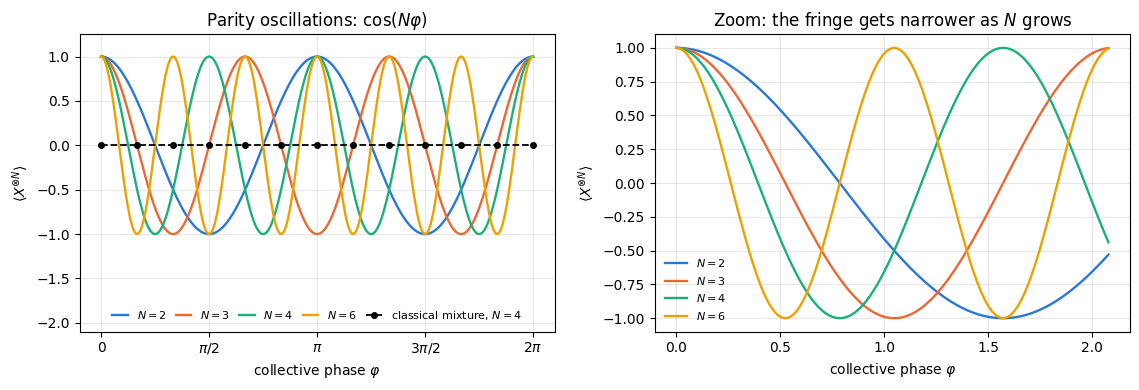

In [10]:
# ==============================================================================
# FIGURE: parity oscillations -- the frequency counts the qubits
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
for k, N in enumerate((2, 3, 4, 6)):
    axes[0].plot(np.asarray(PHI), parity_curves[N], "-", color=PALETTE[k], lw=1.7, label=f"$N={N}$")
axes[0].plot(np.linspace(0, 2 * np.pi, 13), sig_mix, "k--o", ms=4, lw=1.3,
             label="classical mixture, $N=4$")
axes[0].set_xlabel(r"collective phase $\varphi$"); axes[0].set_ylabel(r"$\langle X^{\otimes N}\rangle$")
axes[0].set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
axes[0].set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
axes[0].set_title(r"Parity oscillations: $\cos(N\varphi)$")
axes[0].legend(fontsize=8, ncol=5, loc="lower center", columnspacing=0.8, handlelength=1.4)
axes[0].set_ylim(-2.1, 1.25)

for k, N in enumerate((2, 3, 4, 6)):
    axes[1].plot(np.asarray(PHI)[:120], parity_curves[N][:120], "-", color=PALETTE[k], lw=1.7, label=f"$N={N}$")
axes[1].set_xlabel(r"collective phase $\varphi$"); axes[1].set_ylabel(r"$\langle X^{\otimes N}\rangle$")
axes[1].set_title("Zoom: the fringe gets narrower as $N$ grows"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

Left: $N$ full fringes in $[0,2\pi)$, exactly as Eq. (3) predicts, together with the flat line produced by the classical mixture —
that flat line is what a failed GHZ preparation looks like. Right: the same curves near the origin, where the $N$-fold steepening
of the slope $\partial_\varphi\langle X^{\otimes N}\rangle$ at the zero crossing is visible. That slope is the *signal gain* of
GHZ interferometry; Chapter 10 turns it into the Heisenberg limit.

## 9. The fidelity witness $F>1/2$

### 9.1 Fidelity from populations and parity

Write the projector onto the target state,

$$\vert\mathrm{GHZ}\rangle\langle\mathrm{GHZ}\vert
=\frac12\Big(\vert\bar0\rangle\langle\bar0\vert+\vert\bar1\rangle\langle\bar1\vert
+\vert\bar0\rangle\langle\bar1\vert+\vert\bar1\rangle\langle\bar0\vert\Big),$$

so the fidelity of any state $\rho$ with the GHZ state is

$$F=\langle\mathrm{GHZ}\vert\rho\vert\mathrm{GHZ}\rangle
=\frac{P_{\bar0}+P_{\bar1}}{2}+\mathrm{Re}\,\rho_{\bar0\bar1}
=\frac{P_{\bar0}+P_{\bar1}}{2}+\frac{A}{2}, \tag{4}$$

where $P_{\bar0},P_{\bar1}$ are the two extreme populations (one $Z$-basis measurement setting). The middle expression is exact
for every $\rho$. The last step replaces $\mathrm{Re}\,\rho_{\bar0\bar1}=\vert c\vert\cos(\arg c)$ by $A/2=\vert c\vert$, which
needs $\arg c=0$; in general $A=2\vert c\vert$ is the **amplitude of the parity fringe** of Eq. (3), so Eq. (4) with $A$ is an
*upper bound* on $F$, saturated when the fringe peaks at $\varphi=0$. Experiments arrange exactly that, or equivalently declare
the target to be $(\vert\bar0\rangle+e^{i\arg c}\vert\bar1\rangle)/\sqrt2$, which is GHZ up to one local $Z$ rotation.
That is the recipe of Sackett and co-workers (2000) and of Leibfried and co-workers (2005); both write Eq. (4) with the
magnitude $\vert c\vert$ of the coherence, read off from the fringe amplitude. It needs two measurement settings and a fit,
instead of the $3^N$ settings of full tomography.

### 9.2 Proof that $F>1/2$ certifies genuine multipartite entanglement

Call a pure state **biseparable** if it factorises across *some* bipartition, $\vert\psi\rangle=\vert\alpha\rangle_A\vert\beta\rangle_B$.
A mixed state is biseparable if it is a mixture of such states (possibly with different cuts). We claim

$$\rho\ \text{biseparable}\ \Longrightarrow\ \langle\mathrm{GHZ}\vert\rho\vert\mathrm{GHZ}\rangle\le\frac12 . \tag{5}$$

*Proof.* For a pure product state across the cut $A\vert B$, expand the GHZ state in its Schmidt form for that cut (Section 3.2),
$\vert\mathrm{GHZ}\rangle=\sum_{k=0,1}\sqrt{\lambda_k}\vert u_k\rangle_A\vert v_k\rangle_B$ with $\lambda_0=\lambda_1=1/2$. Then

$$\vert\langle\mathrm{GHZ}\vert\alpha\beta\rangle\vert
=\Big\vert\sum_k\sqrt{\lambda_k}\,\langle u_k\vert\alpha\rangle\langle v_k\vert\beta\rangle\Big\vert
\le\sqrt{\textstyle\sum_k\lambda_k\vert\langle u_k\vert\alpha\rangle\vert^2}\;
  \sqrt{\textstyle\sum_k\vert\langle v_k\vert\beta\rangle\vert^2}\le\sqrt{\lambda_{\max}}=\frac{1}{\sqrt2},$$

by Cauchy–Schwarz and normalisation. Two facts made this work, and both are special to the GHZ state: its Schmidt rank is $2$
across *every* cut, and both Schmidt coefficients equal $1/2$, so $\lambda_{\max}=1/2$ no matter which cut the biseparable
state happens to use. Squaring gives $F\le1/2$ for pure biseparable states, and the general case follows because
$F$ is linear in $\rho$ and a mixture cannot exceed the largest value among its components. $\square$

The bound is **tight**: taking $\vert\alpha\rangle=\vert u_0\rangle$, $\vert\beta\rangle=\vert v_0\rangle$ saturates both
inequalities, and the simplest example is the product state $\vert\bar0\rangle$, for which $F$ is exactly $1/2$. So $1/2$
cannot be lowered, and the strict inequality $F>1/2$ is the weakest statement that certifies anything.

Contrapositive: **$F>1/2$ certifies that $\rho$ is genuinely $N$-partite entangled.** Equivalently the operator
$\mathcal W=\tfrac12\mathbb 1-\vert\mathrm{GHZ}\rangle\langle\mathrm{GHZ}\vert$ is an **entanglement witness**: $\mathrm{Tr}(\mathcal W\rho)\ge0$
for every biseparable $\rho$, and a negative value proves genuine multipartite entanglement (Gühne and Tóth, 2009).

The implication runs one way only: $F>1/2$ is *sufficient* and not necessary. A state may be genuinely entangled and have small
GHZ fidelity; the witness detects only states close to *this* target. The W state of Section 16 is an example: it is genuinely
$N$-partite entangled, and its fidelity with $\vert\mathrm{GHZ}_N\rangle$ is exactly $0$ (it contains only strings with a single
$1$, the GHZ state only $0\cdots0$ and $1\cdots1$).

In [11]:
# ==============================================================================
# STEP 7: the witness -- fidelity from populations + parity, and its value on separable references
# ==============================================================================
def ghz_fidelity_dm(rho_tensor):
    """F = <GHZ|rho|GHZ> for a density tensor (exact, by contraction with the GHZ vector)."""
    N = rho_tensor.ndim // 2
    v = ghz_state(N).reshape(-1)
    return float(jnp.real(jnp.vdot(v, dm_matrix(rho_tensor) @ v)))


def populations_and_coherence(rho_tensor):
    """(P_{0..0}, P_{1..1}, rho_{0..0,1..1}) of a density tensor -- the three numbers Eq. (4) needs."""
    M = dm_matrix(rho_tensor)
    return float(jnp.real(M[0, 0])), float(jnp.real(M[-1, -1])), complex(M[0, -1])


N_W = 4
tests = {
    "ideal GHZ": to_dm(ghz_state(N_W)),
    "classical mixture, Eq. (2)": dm_tensor(mix4, 4),
    "product state |+>^N": to_dm(product_state("+" * N_W)),
    "Bell pair (0,1) x |00>": to_dm(jnp.einsum("ab,c,d->abcd", 2 ** -0.5 * jnp.array([[1, 0], [0, 1]], CDTYPE),
                                               jnp.array([1, 0], CDTYPE), jnp.array([1, 0], CDTYPE))),
}
print(f"{'state':>28s} {'P_0bar':>8s} {'P_1bar':>8s} {'Re c':>8s} {'F (exact)':>10s} {'Eq. (4)':>9s} "
      f"{'witness Tr(W rho)':>18s}")
for name, r in tests.items():
    p0, p1, c = populations_and_coherence(r)
    F, F4 = ghz_fidelity_dm(r), (p0 + p1) / 2 + c.real
    print(f"{name:>28s} {p0:8.4f} {p1:8.4f} {c.real:8.4f} {F:10.6f} {F4:9.6f} {0.5 - F:18.6f}"
          + ("   <- genuinely N-partite" if F > 0.5 + 1e-12 else ""))
    assert abs(F - F4) < 1e3 * TOL
    assert (F > 0.5) == (name == "ideal GHZ")             # only the GHZ state may fire the witness
print("\nA negative witness value Tr(W rho) = 1/2 - F proves genuine N-partite entanglement (Eq. 5).")


# --- CHECKPOINT: Eq. (5) itself, on random pure BISEPARABLE states ----------------------------------
# The four states above are hand-picked, so they test nothing about the theorem. Here we draw Haar-random
# states on each side of every one of the 2^{N-1}-1 = 7 cuts of four qubits and check that none reaches 1/2.
def rand_state(key, n):
    """A Haar-random normalised n-qubit state tensor (complex Gaussian amplitudes, then normalise)."""
    kr, ki = jax.random.split(key)
    v = jax.random.normal(kr, (2 ** n,)) + 1j * jax.random.normal(ki, (2 ** n,))
    return (v / jnp.linalg.norm(v)).astype(CDTYPE).reshape((2,) * n)


v_ghz = ghz_state(N_W).reshape(-1)
key_bs, worst_bs, n_bs = jax.random.PRNGKey(7), 0.0, 0
for k in range(1, N_W):
    for A in itertools.combinations(range(N_W), k):
        B = tuple(q for q in range(N_W) if q not in A)
        order = np.argsort(np.array(A + B))                       # put the axes back in qubit order
        for _ in range(40):
            key_bs, ka, kb = jax.random.split(key_bs, 3)
            psi_bs = jnp.transpose(jnp.tensordot(rand_state(ka, k), rand_state(kb, N_W - k), axes=0), order)
            worst_bs = max(worst_bs, float(jnp.abs(jnp.vdot(v_ghz, psi_bs.reshape(-1))) ** 2))
            n_bs += 1
F_tight = float(jnp.abs(jnp.vdot(v_ghz, product_state("0" * N_W).reshape(-1))) ** 2)
print(f"largest F over {n_bs} random pure biseparable states (all 7 cuts): {worst_bs:.6f}   <= 1/2")
print(f"and the bound is attained: F(|0...0>) = {F_tight:.6f}  ->  Eq. (5) cannot be improved")
assert worst_bs < 0.5 and abs(F_tight - 0.5) < 1e3 * TOL

                       state   P_0bar   P_1bar     Re c  F (exact)   Eq. (4)  witness Tr(W rho)
                   ideal GHZ   0.5000   0.5000   0.5000   1.000000  1.000000          -0.500000   <- genuinely N-partite
  classical mixture, Eq. (2)   0.5000   0.5000   0.0000   0.500000  0.500000           0.000000
         product state |+>^N   0.0625   0.0625   0.0625   0.125000  0.125000           0.375000
      Bell pair (0,1) x |00>   0.5000   0.0000   0.0000   0.250000  0.250000           0.250000

A negative witness value Tr(W rho) = 1/2 - F proves genuine N-partite entanglement (Eq. 5).


largest F over 560 random pure biseparable states (all 7 cuts): 0.295792   <= 1/2
and the bound is attained: F(|0...0>) = 0.500000  ->  Eq. (5) cannot be improved


Equation (4) reproduces the exact fidelity in every case. Only the ideal GHZ state has $F>1/2$; the classical mixture sits
exactly *at* the boundary $F=1/2$ (it is separable, so the witness correctly fails to certify it), and the two other separable
references sit below. The largest fidelity reached by $560$ random pure biseparable states is $0.296$, well inside the bound,
and the product state $\vert\bar0\rangle$ attains $1/2$ exactly.

## 10. Decoherence: what the three channels do to one qubit

We now expose the state to noise. Every channel acts **locally and independently on each qubit** — the realistic situation in
hardware, where each ion or transmon talks to its own environment. All three are defined in the engine recap; here is what each
does to a single-qubit density matrix $\rho=\begin{pmatrix}\rho_{00}&\rho_{01}\\ \rho_{10}&\rho_{11}\end{pmatrix}$:

| channel | Kraus operators | action |
|---|---|---|
| dephasing, strength $p$ | $\sqrt{1-p}\,\mathbb 1$, $\sqrt p\,Z$ | $\rho_{01}\to(1-2p)\rho_{01}$, populations unchanged |
| depolarising, strength $p$ | $\sqrt{1-p}\,\mathbb 1$, $\sqrt{p/3}\,X,Y,Z$ | every Pauli expectation $\to\lambda\,\cdot$, $\lambda=1-\tfrac{4p}{3}$ |
| amplitude damping, strength $\gamma$ | $\mathrm{diag}(1,\sqrt{1-\gamma})$, $\sqrt\gamma\,\vert0\rangle\langle1\vert$ | $\rho_{11}\to(1-\gamma)\rho_{11}$, $\rho_{01}\to\sqrt{1-\gamma}\,\rho_{01}$ |

The dephasing line follows from $Z\rho Z$ flipping the sign of the off-diagonal: $(1-p)\rho_{01}+p(-\rho_{01})=(1-2p)\rho_{01}$.

The depolarising line needs one line of algebra. Two Pauli matrices either commute or anticommute, so
$\sigma_k\sigma_a\sigma_k=\pm\sigma_a$ with $+$ if they commute and $-$ if they anticommute, and by the cyclic property of
the trace $\mathrm{Tr}(\sigma_a\,\sigma_k\rho\,\sigma_k)=\mathrm{Tr}(\sigma_k\sigma_a\sigma_k\,\rho)=\pm\langle\sigma_a\rangle$.
For a fixed $a\in\{x,y,z\}$, one of the three $\sigma_k$ is $\sigma_a$ itself (commutes, $+$) and the other two anticommute
with it ($-$). Therefore

$$\langle\sigma_a\rangle\ \longrightarrow\ (1-p)\langle\sigma_a\rangle
 +\frac p3\big(+1-1-1\big)\langle\sigma_a\rangle=\Big(1-p-\frac p3\Big)\langle\sigma_a\rangle
 =\Big(1-\frac{4p}{3}\Big)\langle\sigma_a\rangle,$$

the same factor $\lambda=1-\tfrac{4p}{3}$ for all three components, which is what makes the channel *isotropic*. The amplitude
damping line is read off the Kraus operators directly; trace preservation then fixes the fourth entry,
$\rho_{00}\to\rho_{00}+\gamma\rho_{11}$: population is *moved* to $\vert0\rangle$, and that is the whole difference between
this channel and the other two.

We use these one-qubit facts to derive *exact* $N$-qubit formulas in the next section, so we first verify them numerically.

In [12]:
# ==============================================================================
# STEP 8: single-qubit channel factors -- the numbers every N-qubit formula is built from
# ==============================================================================
CHANNELS = {"dephasing": kraus_dephasing, "depolarising": kraus_depolarizing,
            "amplitude damping": kraus_amplitude_damping}

print(f"{'channel':>20s} {'p':>6s} {'coherence factor':>17s} {'predicted':>10s} "
      f"{'<Z> factor':>11s} {'predicted':>10s}")
for name, kr in CHANNELS.items():
    for p in (0.1, 0.3):
        r = jnp.array([[0.5, 0.5], [0.5, 0.5]], dtype=CDTYPE)            # |+><+|: coherence 0.5
        r1 = dm_matrix(apply_kraus_dm(dm_tensor(r, 1), kr(p), [0]))
        f_coh = float(jnp.real(r1[0, 1]) / 0.5)
        rz_ = jnp.array([[0.0, 0.0], [0.0, 1.0]], dtype=CDTYPE)           # |1><1|: <Z> = -1
        r2 = dm_matrix(apply_kraus_dm(dm_tensor(rz_, 1), kr(p), [0]))
        z_after = float(jnp.real(r2[0, 0] - r2[1, 1]))
        pred_c = {"dephasing": 1 - 2 * p, "depolarising": 1 - 4 * p / 3,
                  "amplitude damping": np.sqrt(1 - p)}[name]
        pred_z = {"dephasing": -1.0, "depolarising": -(1 - 4 * p / 3),
                  "amplitude damping": -(1 - 2 * p)}[name]
        print(f"{name:>20s} {p:6.2f} {f_coh:17.9f} {pred_c:10.6f} {z_after:11.6f} {pred_z:10.6f}")
        assert abs(f_coh - pred_c) < 1e3 * TOL and abs(z_after - pred_z) < 1e3 * TOL

             channel      p  coherence factor  predicted  <Z> factor  predicted
           dephasing   0.10       0.800000000   0.800000   -1.000000  -1.000000
           dephasing   0.30       0.400000000   0.400000   -1.000000  -1.000000
        depolarising   0.10       0.866666667   0.866667   -0.866667  -0.866667
        depolarising   0.30       0.600000000   0.600000   -0.600000  -0.600000
   amplitude damping   0.10       0.948683298   0.948683   -0.800000  -0.800000
   amplitude damping   0.30       0.836660027   0.836660   -0.400000  -0.400000


Every single-qubit factor matches the table. The amplitude-damping row differs from the other two: the coherence shrinks by
$\sqrt{1-\gamma}$ while $\langle Z\rangle$ of $\vert1\rangle$ moves as $-(1-2\gamma)$. The channel is *not* unital; it drags the
state towards $\vert0\rangle$ instead of towards the centre of the Bloch sphere. That asymmetry will show up in the GHZ formulas.

## 11. Exact $N$-qubit formulas

### 11.1 Dephasing

The coherence $\rho_{\bar0\bar1}$ connects two basis states that differ on **every single qubit**, so it picks up the
one-qubit factor $N$ times:

$$c(p)=\frac12(1-2p)^N,\qquad \langle X^{\otimes N}\rangle=(1-2p)^N,\qquad
  F(p)=\frac12+\frac{(1-2p)^N}{2}. \tag{6}$$

Populations are untouched, hence $\langle Z_iZ_j\rangle=1$ for all $p$: dephasing leaves the classical correlations perfectly
intact and destroys only the quantum part. This is the cleanest illustration in this notebook of what "coherence" means.

### 11.2 Depolarising

Now use the stabiliser structure. Write $\vert\mathrm{GHZ}\rangle\langle\mathrm{GHZ}\vert=2^{-N}\sum_{P\in\mathcal S}P$, where
$\mathcal S$ is the stabiliser **group**: all $2^N$ products of the generators of Section 5. Depolarising multiplies a Pauli
string of weight $w$ (number of non-identity factors) by $\lambda^{w}$ with $\lambda=1-\tfrac{4p}{3}$, so

$$F(p)=\frac{1}{2^N}\sum_{P\in\mathcal S}\lambda^{w(P)} .$$

The group splits into two halves. The products of the $Z_qZ_{q+1}$ generators are exactly the strings $Z_S$ for subsets $S$ of
**even** size (each generator flips the membership of two neighbouring sites, and such moves generate all even subsets); there
are $2^{N-1}$ of them and $w(Z_S)=\vert S\vert$. Multiplying any of them by $X^{\otimes N}$ gives a string with $X$ on the sites
outside $S$ and $XZ=-iY$ on the sites in $S$ — weight $N$ in every case, another $2^{N-1}$ strings. (The overall factor
$(-i)^{\vert S\vert}=\pm1$ matters if one enumerates the group by hand, as in Exercise 1: for $N=4$ the group element
$X^{\otimes4}Z_0Z_1$ is $-YYXX$, not $+YYXX$. It does not matter here, because only the *weight* enters.) Therefore

$$F(p)=\frac{1}{2^N}\left[\sum_{\vert S\vert\ \text{even}}\lambda^{\vert S\vert}+2^{N-1}\lambda^N\right]
=\frac12\left[\Big(\frac{1+\lambda}{2}\Big)^{N}+\Big(\frac{1-\lambda}{2}\Big)^{N}\right]+\frac{\lambda^N}{2}, \tag{7}$$

where we used the binomial identity $\sum_{\vert S\vert\text{ even}}\lambda^{\vert S\vert}=\tfrac12[(1+\lambda)^N+(1-\lambda)^N]$.
Nothing was expanded or truncated: Eq. (7) is **exact** for every $N$ and every $p$. The only step that needs care is
$F=\mathrm{Tr}\big(\Lambda(\rho)\rho\big)=4^{-N}\sum_{P,Q\in\mathcal S}\lambda^{w(P)}\mathrm{Tr}(PQ)$, where
$\mathrm{Tr}(PQ)=2^N\delta_{PQ}$ because the product of two distinct stabiliser elements is a third one, never $\pm\mathbb 1$,
and every Pauli string other than the identity is traceless.
Check the limits: $\lambda=1$ gives $F=\tfrac12[1+0]+\tfrac12=1$; $\lambda=0$ (i.e. $p=3/4$) gives $F=2^{-N}$, the fidelity of
the maximally mixed state. Along the way we also get

$$\langle X^{\otimes N}\rangle=\lambda^N,\qquad \langle Z_iZ_j\rangle=\lambda^2 .$$

### 11.3 Amplitude damping

Each qubit decays independently, $\vert1\rangle\to\vert0\rangle$ with probability $\gamma$. Then
$\rho_{\bar1\bar1}\to(1-\gamma)^N/2$, the $\vert\bar0\rangle$ population gains the probability $\gamma^N$ that **all** qubits
decayed, and the coherence picks up $\sqrt{1-\gamma}$ per qubit:

$$\langle X^{\otimes N}\rangle=(1-\gamma)^{N/2},\qquad
  F(\gamma)=\frac14\Big(1+\gamma^N+(1-\gamma)^N\Big)+\frac{(1-\gamma)^{N/2}}{2}. \tag{8}$$

For $\langle Z_iZ_j\rangle$: the $\vert\bar0\rangle$ branch contributes $+1$; in the $\vert\bar1\rangle$ branch each qubit is
still $\vert1\rangle$ with probability $1-\gamma$, giving $\langle Z_q\rangle=\gamma-(1-\gamma)=-(1-2\gamma)$ independently, so

$$\langle Z_iZ_j\rangle=\frac{1+(1-2\gamma)^2}{2}. \tag{9}$$

At complete damping $F(\gamma=1)=1/2$: the state is the product $\vert\bar0\rangle$, which has overlap $1/2$ with the GHZ state
and sits exactly on the witness boundary of Section 9. For $N\ge3$ the fidelity is therefore **not monotonic** in $\gamma$. It
first falls below $1/2$ (the coherence and $P_{\bar1}$ decay), reaches a minimum, and returns to $1/2$ as $\gamma\to1$, because
the term $\gamma^N/4$, the probability that every qubit has decayed into $\vert\bar0\rangle$, takes over. A fidelity close to
$1/2$ can thus describe a product state.

All of Eqs. (6)–(9) are now checked against the exact density tensor.

In [13]:
# ==============================================================================
# STEP 9: exact density-tensor evolution under local noise, vs the analytic formulas
# ==============================================================================
def noisy_ghz_dm(N, kraus_p):
    """GHZ_N sent through the SAME single-qubit channel on every qubit; returns the rank-2N density tensor."""
    rho = to_dm(ghz_state(N))
    for q in range(N):
        rho = apply_kraus_dm(rho, kraus_p, [q])
    return rho


def dm_observables(rho_tensor):
    """(fidelity with GHZ, <X...X>, <Z_0 Z_1>) of a density tensor -- the three quantities we track."""
    N = rho_tensor.ndim // 2
    par = float(expect_pauli_string_dm(rho_tensor, "X" * N))
    zz = float(expect_pauli_string_dm(rho_tensor, "ZZ" + "I" * (N - 2)))
    return ghz_fidelity_dm(rho_tensor), par, zz


def analytic(name, N, p):
    """(F, <X...X>, <Z_0 Z_1>) from Eqs. (6)-(9)."""
    if name == "dephasing":
        s = (1 - 2 * p) ** N
        return 0.5 + s / 2, s, 1.0
    if name == "depolarising":
        lam = 1 - 4 * p / 3
        F = 0.5 * (((1 + lam) / 2) ** N + ((1 - lam) / 2) ** N) + lam ** N / 2
        return F, lam ** N, lam ** 2
    lam = 1 - p                                                   # amplitude damping, p = gamma
    F = 0.25 * (1 + p ** N + lam ** N) + lam ** (N / 2) / 2
    return F, lam ** (N / 2), (1 + (1 - 2 * p) ** 2) / 2


P_GRID = np.array([0.0, 0.02, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50])
dm_data = {}
err_formula = 0.0
for name, kr in CHANNELS.items():
    for N in (2, 4, 6):
        F_, X_, Z_ = [], [], []
        for p in P_GRID:
            o = dm_observables(noisy_ghz_dm(N, kr(float(p))))
            a = analytic(name, N, float(p))
            err_formula = max(err_formula, max(abs(x - y) for x, y in zip(o, a)))
            F_.append(o[0]); X_.append(o[1]); Z_.append(o[2])
        dm_data[(name, N)] = (np.array(F_), np.array(X_), np.array(Z_))
    print(f"{name:>18s}:  N = 6, p = 0.10  ->  F = {dm_data[(name, 6)][0][3]:.6f}, "
          f"<X...X> = {dm_data[(name, 6)][1][3]:.6f}, <Z0Z1> = {dm_data[(name, 6)][2][3]:.6f}")
print(f"\nlargest discrepancy between the exact density tensor and Eqs. (6)-(9), over "
      f"{len(CHANNELS) * 3 * len(P_GRID)} (channel, N, p) combinations and 3 observables: {err_formula:.2e}")
assert err_formula < 1e-9

         dephasing:  N = 6, p = 0.10  ->  F = 0.631072, <X...X> = 0.262144, <Z0Z1> = 1.000000


      depolarising:  N = 6, p = 0.10  ->  F = 0.542391, <X...X> = 0.423753, <Z0Z1> = 0.751111
 amplitude damping:  N = 6, p = 0.10  ->  F = 0.747360, <X...X> = 0.729000, <Z0Z1> = 0.820000

largest discrepancy between the exact density tensor and Eqs. (6)-(9), over 72 (channel, N, p) combinations and 3 observables: 1.11e-15


Every one of the $72$ numbers produced by explicit Kraus evolution of the density tensor agrees with the closed-form
expressions to better than $10^{-9}$. The formulas are now trustworthy, and we can use them wherever a density tensor is too
expensive.

Look at the $N=6$, $p=0.1$ line in the printout. Dephasing has already cut the coherence to $(0.8)^6\approx0.26$ while leaving
$\langle Z_0Z_1\rangle$ at exactly $1$. Depolarising, with $\lambda=1-0.4/3\approx0.867$, damages *both*. Amplitude damping is the
gentlest on the coherence ($\sqrt{0.9}^{\,6}=0.9^3=0.729$) but it moves the populations, which is why its fidelity behaves
differently again.

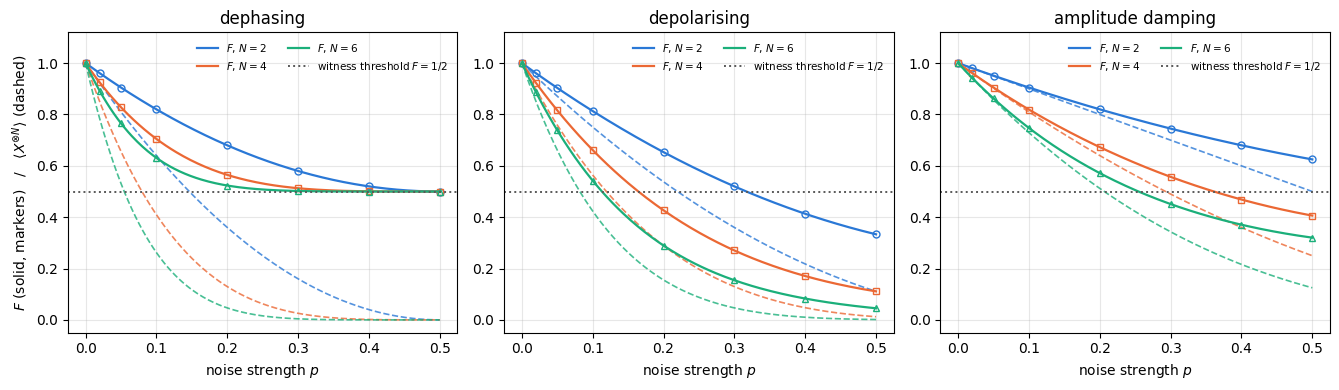

In [14]:
# ==============================================================================
# FIGURE: exact decoherence of GHZ_N -- three channels, three observables
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0), sharex=True)
pfine = np.linspace(0, 0.5, 200)
for j, (name, _) in enumerate(CHANNELS.items()):
    ax = axes[j]
    for k, N in enumerate((2, 4, 6)):
        ax.plot(pfine, [analytic(name, N, p)[0] for p in pfine], "-", color=PALETTE[k], lw=1.6,
                label=f"$F$, $N={N}$")
        ax.plot(P_GRID, dm_data[(name, N)][0], MARKERS[k], color=PALETTE[k], ms=5, mfc="none")
        ax.plot(pfine, [analytic(name, N, p)[1] for p in pfine], "--", color=PALETTE[k], lw=1.2, alpha=0.8)
    ax.axhline(0.5, color="0.35", ls=":", lw=1.4, label=r"witness threshold $F=1/2$")
    ax.set_xlabel("noise strength $p$")
    if j == 0:
        ax.set_ylabel(r"$F$ (solid, markers)   /   $\langle X^{\otimes N}\rangle$ (dashed)")
    ax.set_title(name); ax.set_ylim(-0.05, 1.12); ax.legend(fontsize=7.5, ncol=2, loc="upper right")
fig.tight_layout(); plt.show()

Solid lines and open markers: the GHZ fidelity from Eqs. (6)–(8) and from the exact density tensor, indistinguishable. Dashed
lines: the $N$-body coherence $\langle X^{\otimes N}\rangle$, which always decays faster the larger $N$ is.

The three panels differ qualitatively.
**Dephasing** (left): $F=\tfrac12+\tfrac12(1-2p)^N$ approaches $1/2$ from above but never crosses it, so the witness formally keeps
working for every $p<1/2$ — while the signal it relies on becomes exponentially small in $N$ and would need exponentially many
shots to resolve.
**Depolarising** (middle): $F$ crosses $1/2$ at a finite noise level, and does so earlier for larger $N$.
**Amplitude damping** (right): for $N=2$, $F=1-\gamma+\gamma^2/2=\tfrac12+\tfrac12(1-\gamma)^2$ stays above $1/2$ for every
$\gamma<1$. For $N=4$ and $6$ it crosses $1/2$ inside the plotted range (at $\gamma=0.361$ and $0.255$, Section 15) and is still
falling at $\gamma=0.5$; the return to $1/2$ described in Section 11.3 happens at larger $\gamma$, outside the panel.

## 12. The cost of the exact route and the trajectory unravelling

The density tensor stores $4^N$ complex numbers, $16$ bytes each: $4$ kB for $N=4$, $1$ MB for $N=8$, $256$ MB for $N=12$ and
$4$ GB for $N=14$ — and an out-of-place channel application needs a second copy. Every Kraus channel costs $O(4^N)$ operations
per qubit. This is the hard wall of exact open-system simulation: every further qubit costs a factor of four in both time and
memory. At $N=14$ the $4$ GB still fit into a workstation, but the benchmark of Section 17 extrapolates to the order of an hour per
noisy evaluation; at $N=16$ one copy alone needs $64$ GB.

The **Monte-Carlo wave function** (MCWF, or "quantum trajectory") method trades it for statistics. The identity it rests on is

$$\rho'=\sum_m K_m\rho K_m^\dagger
\quad\text{with}\quad \rho=\vert\psi\rangle\langle\psi\vert
\quad\Longleftrightarrow\quad
\rho'=\mathbb E_m\Big[\vert\psi_m\rangle\langle\psi_m\vert\Big],\;
\vert\psi_m\rangle=\frac{K_m\vert\psi\rangle}{\lVert K_m\vert\psi\rangle\rVert},$$

where the branch $m$ is drawn with probability $p_m=\lVert K_m\vert\psi\rangle\rVert^2$. In words: *pick one Kraus operator at
random with the Born probability, apply it, renormalise*. Averaging the resulting pure states over many runs reproduces the
density matrix exactly — this is what `apply_kraus_mcwf` implements, and it is derived in
[17 — Monte-Carlo wave function](../ch06_open_quantum_systems/17_monte_carlo_wave_function.ipynb).

Memory drops from $4^N$ to $2^N$ per trajectory, and the trajectories are completely independent — the textbook case for
`jax.vmap`. The price is statistical: with $M$ trajectories, the estimate of any observable carries an error $\propto1/\sqrt M$.

> **Common pitfall.** Only **linear** functionals of $\rho$ can be estimated by averaging over trajectories. $F$,
> $\langle X^{\otimes N}\rangle$ and $\langle Z_iZ_j\rangle$ are linear — fine. The negativity, the purity and the von Neumann
> entropy are **not**: $\mathcal N\big(\mathbb E[\rho_m]\big)\ne\mathbb E\big[\mathcal N(\rho_m)\big]$, and averaging the
> trajectory-wise values gives a systematically wrong answer (each trajectory is pure, so its von Neumann entropy is zero). For those one
> must first reconstruct $\bar\rho=\frac1M\sum_m\vert\psi_m\rangle\langle\psi_m\vert$ — which costs $4^N$ again — or use a
> different technique altogether. We demonstrate the failure explicitly below.

In [15]:
# ==============================================================================
# STEP 10: one noisy GHZ trajectory, and a vmap-ed batch of them
# ==============================================================================
def traj_observables(key, kraus, N):
    """ONE trajectory: GHZ_N, then the channel `kraus` applied stochastically to every qubit.
    Returns the three LINEAR observables (F, <X...X>, <Z_0 Z_1>) of the resulting pure state.

    JAX  one PRNG key per qubit (split from `key`); the Kraus branch is chosen by `jax.random.categorical`
         inside `apply_kraus_mcwf`, so nothing here is a Python branch -> jit/vmap safe.
    """
    psi = ghz_state(N)
    keys = jax.random.split(key, N)
    for q in range(N):
        psi = apply_kraus_mcwf(keys[q], psi, kraus, [q])
    v = ghz_state(N).reshape(-1)
    F = jnp.abs(jnp.vdot(v, psi.reshape(-1))) ** 2
    return jnp.stack([F, expect_pauli_string(psi, "X" * N),
                      expect_pauli_string(psi, "ZZ" + "I" * (N - 2))])


@partial(jax.jit, static_argnames=("N",))
def traj_batch(keys, kraus, N):
    """M independent trajectories in one compiled program: vmap over the PRNG keys."""
    return jax.vmap(lambda k: traj_observables(k, kraus, N))(keys)


N_T, P_T, M_T = 6, 0.10, 2048
obs = np.asarray(traj_batch(jax.random.split(jax.random.PRNGKey(0), M_T),
                            kraus_dephasing(P_T), N_T))
mean, sem = obs.mean(axis=0), obs.std(axis=0, ddof=1) / np.sqrt(M_T)
exact = dm_observables(noisy_ghz_dm(N_T, kraus_dephasing(P_T)))
print(f"GHZ_{N_T}, dephasing p = {P_T}, M = {M_T} trajectories\n")
print(f"{'observable':>14s} {'trajectories':>22s} {'exact (density tensor)':>23s} {'pull':>7s}")
for lab, m, s, e in zip(("F", "<X...X>", "<Z0Z1>"), mean, sem, exact):
    pull = (m - e) / s if s > 0 else 0.0
    print(f"{lab:>14s} {m:11.5f} +- {s:7.5f} {e:23.6f} {pull:7.2f}")
    assert abs(m - e) < 5 * max(s, 1e-12)

# --- every Kraus operator is a Pauli matrix times a number: each trajectory ends in P|GHZ>, so F_m is 0 or 1
#     and <X...X>_m is +1 or -1 (the error bars above are binomial, sqrt(F(1-F)/M))
print(f"\nlargest distance of a single-trajectory F from {{0, 1}}: {np.max(np.minimum(obs[:, 0], 1 - obs[:, 0])):.1e};"
      f"  of <X...X> from {{-1, +1}}: {np.max(np.abs(1 - np.abs(obs[:, 1]))):.1e}")
assert np.max(np.minimum(obs[:, 0], 1 - obs[:, 0])) < 1e-9 and np.max(1 - np.abs(obs[:, 1])) < 1e-9

# --- WRONG CONTROL: a coherence factor 1-p per qubit (instead of the engine's 1-2p) must be rejected ----
wrong_X = (1 - P_T) ** N_T
pull_wrong = (mean[1] - wrong_X) / sem[1]
print(f"control: <X...X> against the wrong law (1-p)^N = {wrong_X:.6f} gives a pull of {pull_wrong:+.1f}  (must fail)")
assert abs(pull_wrong) > 5

GHZ_6, dephasing p = 0.1, M = 2048 trajectories

    observable           trajectories  exact (density tensor)    pull
             F     0.62891 +- 0.01068                0.631072   -0.20
       <X...X>     0.25781 +- 0.02136                0.262144   -0.20
        <Z0Z1>     1.00000 +- 0.00000                1.000000    0.00

largest distance of a single-trajectory F from {0, 1}: 0.0e+00;  of <X...X> from {-1, +1}: 2.2e-16
control: <X...X> against the wrong law (1-p)^N = 0.531441 gives a pull of -12.8  (must fail)


All three trajectory estimates agree with the exact density-tensor values within their statistical error bars (the "pull" column,
deviation divided by standard error, is $O(1)$). The observable $\langle Z_0Z_1\rangle$ has *zero* error bar: under dephasing every
individual trajectory has $\langle Z_0Z_1\rangle=1$ exactly, because $Z$ errors do not touch populations; the vanishing variance
is a property of this unravelling.

The other two error bars can be predicted as well. Both Kraus operators of the dephasing channel (and all four of the
depolarising channel) are Pauli matrices times numbers, so every trajectory ends in $P\vert\mathrm{GHZ}\rangle$ for some Pauli
string $P$. A Pauli string maps the GHZ basis $(\vert x\rangle\pm\vert\bar x\rangle)/\sqrt2$ onto itself up to a phase, hence
$P\vert\mathrm{GHZ}\rangle$ is either the GHZ state or orthogonal to it, and $F_m\in\{0,1\}$; likewise $P$ commutes or
anticommutes with $X^{\otimes N}$, so $\langle X^{\otimes N}\rangle_m=\pm1$. The estimates are binomial, with standard errors
$\sqrt{F(1-F)/M}=0.0107$ and $\sqrt{(1-\langle X^{\otimes N}\rangle^2)/M}=0.0213$, as printed. The control line tests the
channel convention: had `kraus_dephasing(p)` shrunk each coherence by $1-p$, the parity would be $(0.9)^6=0.531$ instead of
$(0.8)^6=0.262$, and the trajectories reject that value by more than ten standard errors.

## 13. $1/\sqrt M$ convergence and calibration of the error bars

The trajectories are independent and identically distributed, so the variance of their mean is

$$\mathrm{Var}\big[\hat O_M\big]=\frac{\mathrm{Var}[O]}{M}\quad\Longrightarrow\quad
  \text{standard error}=\frac{\sigma_O}{\sqrt M}\propto M^{-1/2}.$$

We check both the *scaling* and the *calibration* of the error bars: for each $M$ we run several independent batches and compare
the scatter of their means with the error bar each batch reports. A stochastic estimator whose error bars are not calibrated is
worse than no error bars at all.

For the fidelity there is also an independent prediction. By the argument at the end of Section 12, every depolarising trajectory
has $F_m\in\{0,1\}$, so $\sigma_F=\sqrt{F(1-F)}$ with $F$ from Eq. (7), and the squared deviation of a batch mean from $F$,
divided by $F(1-F)/M$, has expectation exactly $1$. Summed over all $24\times5$ batches this statistic $T$ has mean $120$ and,
for nearly Gaussian batch means, standard deviation $\sqrt{2\cdot120}=15.5$. A test that accepts $T$ within three standard
deviations must also be able to reject error bars that are wrong by a factor of two, which multiply $T$ by $4$ or by $1/4$;
we check that it does.

In [16]:
# ==============================================================================
# STEP 11: convergence study -- error of the MCWF estimate vs the number of trajectories
# ==============================================================================
N_C, P_C, N_REP = 6, 0.20, 24
M_LIST = [16, 64, 256, 1024, 4096]
exact_C = dm_observables(noisy_ghz_dm(N_C, kraus_depolarizing(P_C)))
print(f"GHZ_{N_C}, depolarising p = {P_C}, {N_REP} independent batches per M "
      f"(so the RMS column itself carries a relative uncertainty of about {100 / np.sqrt(2 * (N_REP - 1)):.0f}%)\n")
print(f"{'M':>6s} {'<F> (mean of batches)':>22s} {'RMS error':>11s} {'reported s.e.':>14s} "
      f"{'ratio':>7s} {'exact F':>9s}")
rms_F, sem_F, T_stat = [], [], 0.0
F7 = analytic("depolarising", N_C, P_C)[0]                     # Eq. (7): independent of the trajectory code
key_c = jax.random.PRNGKey(123)
for M in M_LIST:
    means, sems = [], []
    for r in range(N_REP):
        key_c, k = jax.random.split(key_c)
        o = np.asarray(traj_batch(jax.random.split(k, M), kraus_depolarizing(P_C), N_C))
        means.append(o[:, 0].mean()); sems.append(o[:, 0].std(ddof=1) / np.sqrt(M))
    means, sems = np.array(means), np.array(sems)
    rms = np.sqrt(np.mean((means - exact_C[0]) ** 2))
    rms_F.append(rms); sem_F.append(sems.mean())
    T_stat += np.sum((means - F7) ** 2 / (F7 * (1 - F7) / M))
    print(f"{M:6d} {means.mean():22.6f} {rms:11.5f} {sems.mean():14.5f} "
          f"{rms / sems.mean():7.2f} {exact_C[0]:9.6f}   binomial prediction {np.sqrt(F7 * (1 - F7) / M):.5f}")

slope = np.polyfit(np.log(M_LIST), np.log(rms_F), 1)[0]
print(f"\nfitted slope of log(RMS error) vs log(M): {slope:+.3f}   (theory: -0.5; a 1/M law would give -1)")
print(f"mean ratio RMS / reported error bar over all M: {np.mean(np.array(rms_F) / np.array(sem_F)):.2f}  "
      f"(1.0 = perfectly calibrated)")
assert abs(slope + 0.5) < 0.15 and abs(slope + 1.0) > 0.15

# --- CHECKPOINT: calibration against the binomial variance F(1-F)/M, with Eq. (7) for F --------------------
n_b = N_REP * len(M_LIST)
print(f"T = sum over {n_b} batches of (mean - F)^2 / (F(1-F)/M) = {T_stat:.1f}   "
      f"(expected {n_b} +- {np.sqrt(2 * n_b):.1f})")
print(f"controls: error bars too small by 2 -> T = {4 * T_stat:.1f};  too large by 2 -> T = {T_stat / 4:.1f}  (must fail)")
assert abs(T_stat - n_b) < 3 * np.sqrt(2 * n_b)
assert abs(4 * T_stat - n_b) > 3 * np.sqrt(2 * n_b) and abs(T_stat / 4 - n_b) > 3 * np.sqrt(2 * n_b)

GHZ_6, depolarising p = 0.2, 24 independent batches per M (so the RMS column itself carries a relative uncertainty of about 15%)

     M  <F> (mean of batches)   RMS error  reported s.e.   ratio   exact F


    16               0.294271     0.10293        0.11358    0.91  0.289643   binomial prediction 0.11340


    64               0.286458     0.06350        0.05628    1.13  0.289643   binomial prediction 0.05670


   256               0.282878     0.02227        0.02817    0.79  0.289643   binomial prediction 0.02835


  1024               0.289591     0.01289        0.01417    0.91  0.289643   binomial prediction 0.01417


  4096               0.289368     0.00660        0.00709    0.93  0.289643   binomial prediction 0.00709

fitted slope of log(RMS error) vs log(M): -0.511   (theory: -0.5; a 1/M law would give -1)
mean ratio RMS / reported error bar over all M: 0.93  (1.0 = perfectly calibrated)
T = sum over 120 batches of (mean - F)^2 / (F(1-F)/M) = 105.3   (expected 120 +- 15.5)
controls: error bars too small by 2 -> T = 421.2;  too large by 2 -> T = 26.3  (must fail)


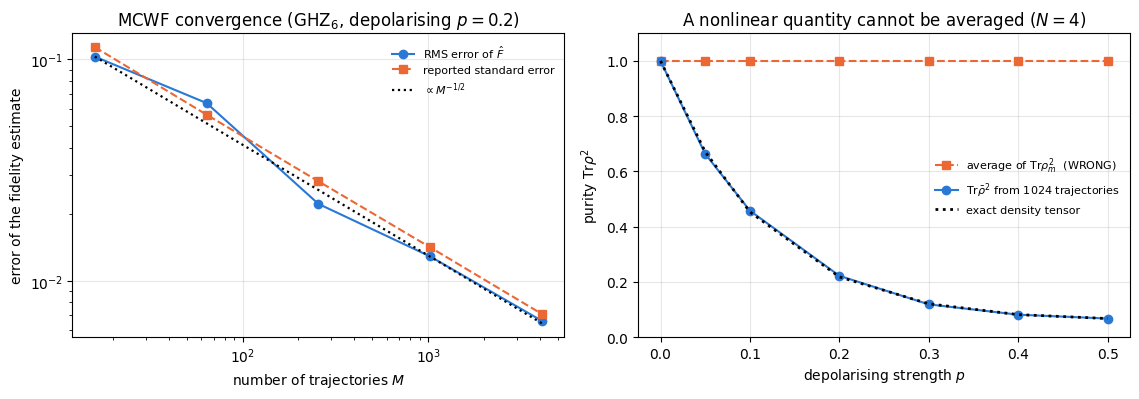

In [17]:
# ==============================================================================
# FIGURE: 1/sqrt(M) convergence, and why nonlinear quantities must NOT be averaged
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.1))
Ms = np.array(M_LIST, dtype=float)
axes[0].loglog(Ms, rms_F, MARKERS[0] + "-", color=PALETTE[0], ms=6, label="RMS error of $\\hat F$")
axes[0].loglog(Ms, sem_F, MARKERS[1] + "--", color=PALETTE[1], ms=6, label="reported standard error")
axes[0].loglog(Ms, rms_F[0] * (Ms / Ms[0]) ** -0.5, "k:", lw=1.6, label=r"$\propto M^{-1/2}$")
axes[0].set_xlabel("number of trajectories $M$"); axes[0].set_ylabel("error of the fidelity estimate")
axes[0].set_title(f"MCWF convergence (GHZ$_{N_C}$, depolarising $p={P_C}$)"); axes[0].legend(fontsize=8)

# the nonlinear trap: purity averaged over trajectories vs purity of the averaged state
keys_nl = jax.random.split(jax.random.PRNGKey(5), 1024)


def one_traj_state(key, kraus, N):
    psi = ghz_state(N)
    ks = jax.random.split(key, N)
    for q in range(N):
        psi = apply_kraus_mcwf(ks[q], psi, kraus, [q])
    return psi.reshape(-1)


pur_avg, pur_of_avg, pur_exact = [], [], []
pgrid_nl = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
for p in pgrid_nl:
    states = jax.jit(jax.vmap(partial(one_traj_state, kraus=kraus_depolarizing(p), N=4)))(keys_nl)
    rho_bar = jnp.einsum("ma,mb->ab", states, jnp.conj(states)) / states.shape[0]
    pur_avg.append(1.0)                                              # every trajectory is PURE: Tr(rho^2) = 1
    pur_of_avg.append(float(purity(rho_bar)))
    pur_exact.append(float(purity(dm_matrix(noisy_ghz_dm(4, kraus_depolarizing(p))))))
axes[1].plot(pgrid_nl, pur_avg, MARKERS[1] + "--", color=PALETTE[1], ms=6,
             label=r"average of $\mathrm{Tr}\rho_m^2$  (WRONG)")
axes[1].plot(pgrid_nl, pur_of_avg, MARKERS[0] + "-", color=PALETTE[0], ms=6,
             label=r"$\mathrm{Tr}\bar\rho^2$ from 1024 trajectories")
axes[1].plot(pgrid_nl, pur_exact, "k:", lw=2, label="exact density tensor")
axes[1].set_xlabel("depolarising strength $p$"); axes[1].set_ylabel(r"purity $\mathrm{Tr}\rho^2$")
axes[1].set_title("A nonlinear quantity cannot be averaged ($N=4$)"); axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 1.1)
fig.tight_layout(); plt.show()

Left: the measured RMS error follows the $M^{-1/2}$ reference line, and the error bars the code *reports* track the error it
actually *makes*. The two curves do not lie exactly on top of each other, and they should not: with a finite number of batches the
RMS column is itself a noisy estimate (its relative uncertainty is printed above the table), so agreement at the ten-per-cent level
is all one can ask for. The sharper test is the statistic $T$, which compares every batch with the binomial variance predicted
from Eq. (7): it lies within its expected range, while error bars wrong by a factor of two would have been rejected. The fitted
slope is close to the theoretical $-1/2$: a hundred times more trajectories buy one extra digit, as for every Monte-Carlo
estimate.

Right: the trap. Averaging the purity *of each trajectory* gives the constant $1$, because every trajectory is a pure state,
whereas the true purity falls to $0.07$ at $p=0.5$. Reconstructing $\bar\rho=\frac1M\sum_m\vert\psi_m\rangle\langle\psi_m\vert$ first and only then computing
$\mathrm{Tr}\bar\rho^2$ reproduces the exact curve. It does so only up to two finite-$M$ effects, and it is worth separating
them. The plug-in estimator is *biased*, because $\mathrm{Tr}\bar\rho^2$ is quadratic in $\bar\rho$:

$$\mathbb E\big[\mathrm{Tr}\bar\rho^{\,2}\big]=\frac1M+\Big(1-\frac1M\Big)\mathrm{Tr}\rho^2
 =\mathrm{Tr}\rho^2+\frac{1-\mathrm{Tr}\rho^2}{M},$$

a positive bias of order $1/M$, here at most $10^{-3}$ and largest where the true purity is smallest. On top of it sits the
ordinary statistical scatter of order $M^{-1/2}$, which at $M=1024$ is a few times larger — which is why the deviations in the
panel are of both signs and do not grow with $p$. The size of the bias is small here; what matters is that it exists: an
estimate of a nonlinear quantity built from $M$ trajectories is biased at every finite $M$, while the trajectory average of a
*linear* observable is unbiased.
Reconstruction also costs $4^N$ memory, so this route does not scale —
but for the *linear* observables of Section 11 no reconstruction is needed at all.

## 14. Reaching $N=12$

Now we use the method for what it is good at. A density tensor at $N=12$ would need $4^{12}=1.7\times10^7$ complex numbers
($256$ MB) and each channel application would touch all of them; a single trajectory needs $2^{12}=4096$ numbers, i.e. $64$ kB,
which fits in a CPU cache, and a batch of a thousand still occupies only $64$ MB. We sweep the noise strength for
$N=4,6,8,10,12$ and compare with the analytic formulas of Section 11. For $N=4$ and $6$ the exact density tensor has already
confirmed those formulas in Section 11; from $N=8$ on the trajectories are the only check we run here. The control at the end
of the cell compares the same trajectories with the other common parametrisation of the depolarising channel,
$\rho\to(1-p)\rho+p\,\mathbb 1/2$, whose Bloch factor is $1-p$ instead of $1-\tfrac{4p}{3}$; it must be rejected.

In [18]:
# ==============================================================================
# STEP 12: noisy GHZ up to N = 12 with trajectories (analytic formulas as the reference)
# ==============================================================================
N_LARGE = [4, 6, 8, 10, 12]
P_LARGE = np.array([0.0, 0.05, 0.10, 0.20, 0.30])
M_LARGE = 1024
CH_LARGE = "depolarising"

big = {}
dist01 = 0.0                                   # largest distance of a single-trajectory F from {0, 1}
t0 = time.perf_counter()
for N in N_LARGE:
    F_m, F_s, X_m, X_s = [], [], [], []
    for i, p in enumerate(P_LARGE):
        keys = jax.random.split(jax.random.PRNGKey(1000 * N + i), M_LARGE)
        o = np.asarray(jax.block_until_ready(traj_batch(keys, kraus_depolarizing(float(p)), N)))
        dist01 = max(dist01, float(np.max(np.minimum(o[:, 0], 1 - o[:, 0]))))
        F_m.append(o[:, 0].mean()); F_s.append(o[:, 0].std(ddof=1) / np.sqrt(M_LARGE))
        X_m.append(o[:, 1].mean()); X_s.append(o[:, 1].std(ddof=1) / np.sqrt(M_LARGE))
    big[N] = tuple(np.array(a) for a in (F_m, F_s, X_m, X_s))
t_big = time.perf_counter() - t0

print(f"{CH_LARGE} channel, {M_LARGE} trajectories per point, total wall time {t_big:.1f} s\n")
print(f"{'N':>3s} {'p':>5s} {'F (MCWF)':>18s} {'F (Eq. 7)':>10s} {'pull':>6s} {'<X..X> (MCWF)':>20s} "
      f"{'Eq. (7)':>9s} {'pull':>6s}")
worst_pull = 0.0
for N in N_LARGE:
    F_m, F_s, X_m, X_s = big[N]
    for i, p in enumerate(P_LARGE):
        aF, aX = analytic(CH_LARGE, N, float(p))[0], analytic(CH_LARGE, N, float(p))[1]
        pF = (F_m[i] - aF) / F_s[i] if F_s[i] > 1e-12 else 0.0
        pX = (X_m[i] - aX) / X_s[i] if X_s[i] > 1e-12 else 0.0
        worst_pull = max(worst_pull, abs(pF), abs(pX))
        print(f"{N:3d} {p:5.2f} {F_m[i]:11.5f} +-{F_s[i]:6.5f} {aF:10.5f} {pF:6.2f} "
              f"{X_m[i]:13.5f} +-{X_s[i]:6.5f} {aX:9.5f} {pX:6.2f}")
n_cmp = len(N_LARGE) * (len(P_LARGE) - 1) * 2
print(f"\nlargest pull over the {n_cmp} comparisons with p > 0: {worst_pull:.2f} sigma"
      f"   (single-trajectory F within {dist01:.0e} of 0 or 1)")
assert worst_pull < 4.5 and dist01 < 1e-9

# --- WRONG CONTROL: the parametrisation rho -> (1-p) rho + p 1/2 (Bloch factor 1-p) must be rejected -------
def eq7_with_lambda(N, lam_):
    """(F, <X...X>) of Eq. (7) for a given Bloch factor lam_."""
    return 0.5 * (((1 + lam_) / 2) ** N + ((1 - lam_) / 2) ** N) + lam_ ** N / 2, lam_ ** N


worst_wrong = max(max(abs(big[N][0][i] - eq7_with_lambda(N, 1 - p)[0]) / big[N][1][i],
                      abs(big[N][2][i] - eq7_with_lambda(N, 1 - p)[1]) / big[N][3][i])
                  for N in N_LARGE for i, p in enumerate(P_LARGE) if p > 0)
print(f"control: F and <X...X> against Eq. (7) with lambda = 1-p instead of 1-4p/3: "
      f"largest pull {worst_wrong:.1f} sigma  (must fail)")
assert worst_wrong > 4.5

depolarising channel, 1024 trajectories per point, total wall time 8.5 s

  N     p           F (MCWF)  F (Eq. 7)   pull        <X..X> (MCWF)   Eq. (7)   pull
  4  0.00     1.00000 +-0.00000    1.00000   0.00       1.00000 +-0.00000   1.00000   0.00
  4  0.05     0.81738 +-0.01208    0.81601   0.11       0.77344 +-0.01982   0.75883   0.74
  4  0.10     0.67578 +-0.01463    0.66151   0.98       0.58203 +-0.02542   0.56417   0.70
  4  0.20     0.41211 +-0.01539    0.42684  -0.96       0.25586 +-0.03022   0.28920  -1.10
  4  0.30     0.26855 +-0.01386    0.27040  -0.13       0.17383 +-0.03079   0.12960   1.44
  6  0.00     1.00000 +-0.00000    1.00000   0.00       1.00000 +-0.00000   1.00000   0.00
  6  0.05     0.76562 +-0.01324    0.73849   2.05       0.68750 +-0.02270   0.66103   1.17
  6  0.10     0.57812 +-0.01544    0.54239   2.31       0.45313 +-0.02787   0.42375   1.05
  6  0.20     0.28711 +-0.01414    0.28964  -0.18       0.16992 +-0.03081   0.15553   0.47
  6  0.30     0.15234 

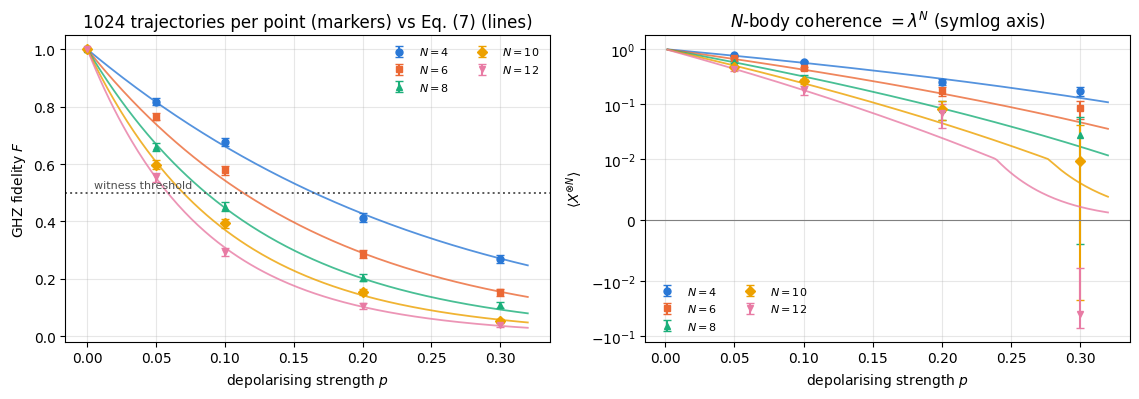

In [19]:
# ==============================================================================
# FIGURE: trajectories up to N = 12 against the analytic formulas
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.1))
pfine = np.linspace(0, 0.32, 200)
for k, N in enumerate(N_LARGE):
    axes[0].errorbar(P_LARGE, big[N][0], yerr=big[N][1], fmt=MARKERS[k % len(MARKERS)], ms=5,
                     color=PALETTE[k % len(PALETTE)], capsize=3, label=f"$N={N}$")
    axes[0].plot(pfine, [analytic(CH_LARGE, N, p)[0] for p in pfine], "-",
                 color=PALETTE[k % len(PALETTE)], lw=1.3, alpha=0.8)
axes[0].axhline(0.5, color="0.35", ls=":", lw=1.4)
axes[0].text(0.005, 0.515, r"witness threshold", fontsize=8, color="0.3")
axes[0].set_xlabel("depolarising strength $p$"); axes[0].set_ylabel(r"GHZ fidelity $F$")
axes[0].set_title(f"{M_LARGE} trajectories per point (markers) vs Eq. (7) (lines)")
axes[0].legend(fontsize=8, ncol=2)

for k, N in enumerate(N_LARGE):
    # SIGNED estimates on a symlog axis: at the largest N and p the estimate can come out negative, and an
    # |.| would hide that (and bias the eye upwards). Below the linear threshold the axis is linear.
    axes[1].errorbar(P_LARGE[1:], big[N][2][1:], yerr=big[N][3][1:],
                     fmt=MARKERS[k % len(MARKERS)], ms=5, color=PALETTE[k % len(PALETTE)], capsize=3,
                     label=f"$N={N}$")
    axes[1].plot(pfine[1:], [analytic(CH_LARGE, N, p)[1] for p in pfine[1:]], "-",
                 color=PALETTE[k % len(PALETTE)], lw=1.3, alpha=0.8)
axes[1].set_yscale("symlog", linthresh=1e-2)
axes[1].axhline(0.0, color="0.5", lw=0.8)
axes[1].set_xlabel("depolarising strength $p$"); axes[1].set_ylabel(r"$\langle X^{\otimes N}\rangle$")
axes[1].set_title(r"$N$-body coherence $=\lambda^N$ (symlog axis)"); axes[1].legend(fontsize=8, ncol=2)
fig.tight_layout(); plt.show()

The trajectory estimates sit on the analytic curves within their error bars for every $N$ up to $12$; the largest deviation
over the $40$ comparisons with $p>0$ is the $2.3\sigma$ printed above (at $p=0$ every trajectory is exact and the error bar is
zero). That is an ordinary value for the largest of $40$ standard normal deviates, although the $F$ and the parity estimate at
the same $(N,p)$ come from the same trajectories and are correlated. The control with the Bloch factor $1-p$ is rejected
by many standard deviations, so the agreement singles out the engine's convention $\lambda=1-\tfrac{4p}{3}$. The right
panel, on a symmetric-log axis, shows the fragility directly: at fixed $p$ the curves for $N=4,6,8,10,12$ are spaced by
equal *factors* (above $10^{-2}$, where the axis is logarithmic), because the coherence is $\lambda^N$ and each additional
pair of qubits multiplies the signal by the same $\lambda^2<1$. (The $N=12$, $p=0.30$ point comes out slightly *negative*: the true value
there is $0.002$ and the standard error is $0.031$, so a negative estimate is the expected behaviour of an unbiased estimator
at a value indistinguishable from zero. Plotting $\vert\langle X^{\otimes N}\rangle\vert$ instead would have hidden that.)

The error bars follow from the binomial argument of Section 12. The fidelity error is $\sqrt{F(1-F)/M}$: largest,
$1/(2\sqrt M)=0.0156$, where $F\approx1/2$, and small where $F$ is close to $0$ or $1$ ($0.006$ at $N=12$, $p=0.3$). The parity
error is $\sqrt{(1-\lambda^{2N})/M}$, which tends to $1/\sqrt{M}=0.031$ as the signal vanishes. The *relative* error of the
coherence is therefore $\approx\lambda^{-N}/\sqrt M$, and estimating an exponentially small coherence to a fixed relative
accuracy requires exponentially many trajectories, the same problem an experiment has with shots.

## 15. Fragility: the closing of the useful window

Two ways to quantify "GHZ states get harder as $N$ grows".

**Coherence half-point.** From Eq. (6), the dephasing strength at which the $N$-body coherence has dropped to half its value is

$$(1-2p_{1/2})^N=\tfrac12\ \Longrightarrow\ p_{1/2}=\frac{1-2^{-1/N}}{2}\ \simeq\ \frac{\ln2}{2N}\quad(N\gg1),$$

an inverse-linear shrinking of the tolerable noise. Equivalently, at fixed $p$ the coherence time of an $N$-qubit GHZ state is
$N$ times shorter than that of a single qubit. The expansion also explains why a power law fitted over a *finite* window comes
out slightly shallower than $-1$: writing $x=\ln2/N$,
$p_{1/2}=\tfrac12(1-e^{-x})=\tfrac{x}{2}\big(1-\tfrac x2+O(x^2)\big)$, so
$\mathrm{d}\ln p_{1/2}/\mathrm{d}\ln N=-1+\tfrac{\ln2}{2N}+O(N^{-2})$. Over $N=2,\dots,20$ the fit below returns $-0.944$;
over $N=100,\dots,10^4$ the same fit returns $-1.000$.

> **Physics insight.** The $1/N$ law assumes that each qubit sees its *own*, statistically independent environment. If instead
> the fluctuating field is the same for all qubits — a common-mode magnetic field across a small ion crystal — the random
> phases add coherently, $\sum_q\varphi_q=N\varphi$, the variance of the accumulated phase grows as $N^2\sigma^2$ instead of
> $N\sigma^2$, and the decoherence *rate* grows as $N^2$. That "superdecoherence" is what Monz and co-workers observed on up
> to eight ions in the experiment that produced the $14$-qubit GHZ state; notebook
> [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb)
> derives the two cases side by side. Everything in this notebook is the independent-environment case.

**Witness threshold.** For depolarising noise, the $p$ at which $F$ of Eq. (7) crosses $1/2$ marks the point where the standard
certificate stops working. There is no closed form at finite $N$, so we bisect — but the large-$N$ limit *is* closed. Put
$p=c/N$ in Eq. (7): $\lambda^N\to e^{-4c/3}$, $\big(\tfrac{1+\lambda}{2}\big)^N=\big(1-\tfrac{2c}{3N}\big)^N\to e^{-2c/3}$ and
$\big(\tfrac{1-\lambda}{2}\big)^N\to0$, so $F=\tfrac12$ becomes $u+u^2=1$ with $u=e^{-2c/3}$, i.e. $u=1/\varphi$ with
$\varphi=\tfrac{1+\sqrt5}{2}$ the golden ratio, and

$$p_{\rm crit}^{\rm depol}\ \simeq\ \frac{3\ln\varphi}{2N}=\frac{0.72182}{N}.$$

The same substitution in Eq. (8) gives $\big(1+e^{-c/2}\big)^2=2$, hence
$p_{\rm crit}^{\rm damp}\simeq2\ln(1+\sqrt2)/N=1.76275/N$. Both limits are checked numerically below, together with power laws
fitted at finite $N$ ($N=2,\dots,20$ for $p_{1/2}$, $N=6,\dots,20$ for the depolarising threshold).

In [20]:
# ==============================================================================
# STEP 13: critical noise levels vs N
# ==============================================================================
def bisect_threshold(fun, target, lo, hi, iters=80):
    """Bisection for fun(p) = target on [lo, hi] with fun decreasing."""
    for _ in range(iters):
        mid = 0.5 * (lo + hi)
        lo, hi = (mid, hi) if fun(mid) > target else (lo, mid)
    return 0.5 * (lo + hi)


N_FRAG = np.arange(2, 21)
p_half = (1 - 2.0 ** (-1.0 / N_FRAG)) / 2                                     # dephasing coherence half-point
p_wit = np.array([bisect_threshold(lambda p: analytic("depolarising", int(N), p)[0], 0.5, 0.0, 0.75)
                  for N in N_FRAG])
p_wit_ad = np.array([bisect_threshold(lambda p: analytic("amplitude damping", int(N), p)[0], 0.5, 0.0, 1.0)
                     for N in N_FRAG])

sl_half = np.polyfit(np.log(N_FRAG), np.log(p_half), 1)[0]
sl_wit = np.polyfit(np.log(N_FRAG[4:]), np.log(p_wit[4:]), 1)[0]
print(f"{'N':>3s} {'p_1/2 (dephasing)':>19s} {'ln2/(2N)':>10s} {'p_crit (depol.)':>16s} "
      f"{'p_crit (amp.damp.)':>19s}")
for i, N in enumerate(N_FRAG):
    if N in (2, 3, 4, 6, 8, 10, 14, 20):
        print(f"{N:3d} {p_half[i]:19.5f} {np.log(2) / (2 * N):10.5f} {p_wit[i]:16.5f} {p_wit_ad[i]:19.5f}")
print(f"\nfitted power law:  p_1/2 ~ N^({sl_half:+.3f}) over N = 2..20      "
      f"p_crit(depolarising) ~ N^({sl_wit:+.3f}) over N = 6..20   (asymptotically both are 1/N)")
assert abs(sl_half + 1.0) < 0.12 and abs(sl_wit + 1.0) < 0.2

# --- a checkpoint on the bisection: the witness threshold really is where F = 1/2 -------------------
chk = max(abs(analytic("depolarising", int(N), float(p))[0] - 0.5) for N, p in zip(N_FRAG, p_wit))
print(f"max |F(p_crit) - 1/2| over all N: {chk:.2e}")
assert chk < 1e-9

# --- the exponent is exactly -1 only asymptotically: widen the fitting window ------------------------
for lo, hi in ((2, 21), (2, 101), (100, 10001)):
    Nw = np.arange(lo, hi)
    print(f"p_1/2 fitted over N = {lo}..{hi - 1:5d}:  exponent {np.polyfit(np.log(Nw), np.log((1 - 2.0 ** (-1.0 / Nw)) / 2), 1)[0]:+.4f}")

# --- CHECKPOINT: the closed-form large-N constants of the two witness thresholds ---------------------
C_DEPOL = 1.5 * np.log((1 + np.sqrt(5)) / 2)               # 3 ln(golden ratio) / 2
C_DAMP = 2 * np.log(1 + np.sqrt(2))
print(f"\nlarge-N limits:  N p_crit -> 3 ln(phi)/2 = {C_DEPOL:.6f} (depolarising),"
      f"  2 ln(1+sqrt 2) = {C_DAMP:.6f} (amplitude damping)")
for N in (20, 200, 2000, 20000):
    npd = N * bisect_threshold(lambda p: analytic("depolarising", N, p)[0], 0.5, 0.0, 0.75)
    npa = N * bisect_threshold(lambda p: analytic("amplitude damping", N, p)[0], 0.5, 0.0, 1.0)
    print(f"   N = {N:6d}:  N p_crit = {npd:.6f} (depol.)   {npa:.6f} (amp. damp.)")
assert abs(npd - C_DEPOL) < 1e-4 and abs(npa - C_DAMP) < 1e-4

  N   p_1/2 (dephasing)   ln2/(2N)  p_crit (depol.)  p_crit (amp.damp.)
  2             0.14645    0.17329          0.31699             1.00000
  3             0.10315    0.11552          0.21345             0.48051
  4             0.07955    0.08664          0.16448             0.36110
  6             0.05455    0.05776          0.11307             0.25463
  8             0.04150    0.04332          0.08612             0.19776
 10             0.03348    0.03466          0.06954             0.16161
 14             0.02415    0.02476          0.05020             0.11831
 20             0.01703    0.01733          0.03542             0.08436

fitted power law:  p_1/2 ~ N^(-0.944) over N = 2..20      p_crit(depolarising) ~ N^(-0.966) over N = 6..20   (asymptotically both are 1/N)
max |F(p_crit) - 1/2| over all N: 8.33e-16
p_1/2 fitted over N = 2..   20:  exponent -0.9440
p_1/2 fitted over N = 2..  100:  exponent -0.9771
p_1/2 fitted over N = 100..10000:  exponent -0.9997

large-N limits: 

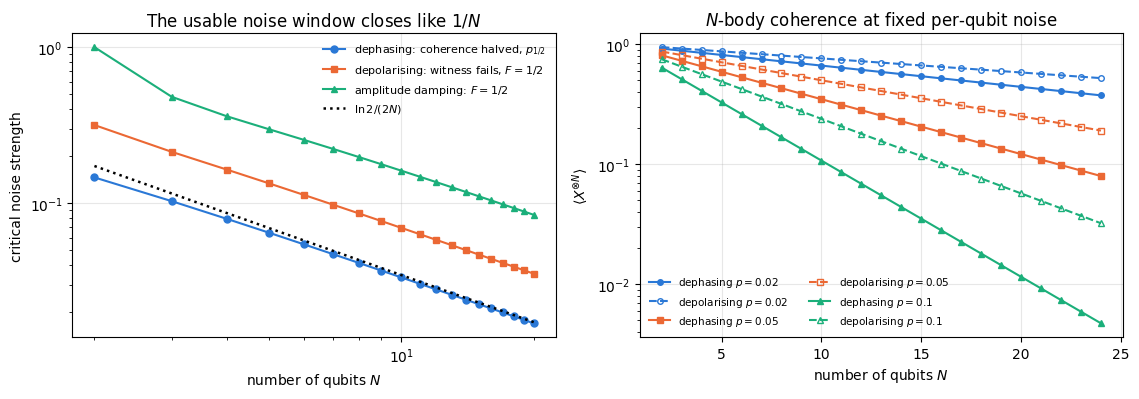

In [21]:
# ==============================================================================
# FIGURE: fragility -- the tolerable noise shrinks like 1/N
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.1))
axes[0].loglog(N_FRAG, p_half, MARKERS[0] + "-", color=PALETTE[0], ms=5,
               label=r"dephasing: coherence halved, $p_{1/2}$")
axes[0].loglog(N_FRAG, p_wit, MARKERS[1] + "-", color=PALETTE[1], ms=5,
               label=r"depolarising: witness fails, $F=1/2$")
axes[0].loglog(N_FRAG, p_wit_ad, MARKERS[2] + "-", color=PALETTE[2], ms=5,
               label=r"amplitude damping: $F=1/2$")
axes[0].loglog(N_FRAG, np.log(2) / (2 * N_FRAG), "k:", lw=1.8, label=r"$\ln 2/(2N)$")
axes[0].set_xlabel("number of qubits $N$"); axes[0].set_ylabel("critical noise strength")
axes[0].set_title("The usable noise window closes like $1/N$"); axes[0].legend(fontsize=8)

pshow = [0.02, 0.05, 0.10]
Nc = np.arange(2, 25)
for k, p in enumerate(pshow):
    axes[1].semilogy(Nc, (1 - 2 * p) ** Nc, MARKERS[k] + "-", color=PALETTE[k], ms=4,
                     label=f"dephasing $p={p}$")
    axes[1].semilogy(Nc, (1 - 4 * p / 3) ** Nc, MARKERS[k] + "--", color=PALETTE[k], ms=4, mfc="none",
                     label=f"depolarising $p={p}$")
axes[1].set_xlabel("number of qubits $N$"); axes[1].set_ylabel(r"$\langle X^{\otimes N}\rangle$")
axes[1].set_title("$N$-body coherence at fixed per-qubit noise"); axes[1].legend(fontsize=7.5, ncol=2)
fig.tight_layout(); plt.show()

Left: all three thresholds fall on straight lines of slope close to $-1$ in the log-log plot — the tolerable per-qubit noise is
inversely proportional to the number of qubits, so doubling the register halves the error budget per gate and per microsecond.
(The single visible exception is amplitude damping at $N=2$, where $F$ reaches $1/2$ only at complete damping $\gamma=1$, because a
fully damped state is $\vert\bar0\rangle$ and that still has overlap $1/2$ with a two-qubit GHZ state. From $N=3$ on the curve is a
clean power law.)

Right: at *fixed* per-qubit noise the coherence decays exponentially in $N$ — a straight line on the logarithmic axis. At a very
modest dephasing $p=0.02$ a $24$-qubit GHZ state retains only about $38\%$ of its coherence, and at $p=0.1$ only about $0.5\%$.
Depolarising noise of the same nominal strength is *milder* on the coherence — its per-qubit factor is $1-\tfrac{4p}{3}$ against
dephasing's $1-2p$ — but it attacks the populations and the two-qubit correlators as well, which dephasing leaves untouched.
**The gate count grows only linearly in $N$; the coherence decays exponentially in $N$, and that decay is what makes large GHZ
states hard.**

## 16. The other kind of multipartite entanglement: the W state

The GHZ state is one of several ways for $N$ qubits to be entangled. The **W state**

$$\vert W_N\rangle=\frac{1}{\sqrt N}\Big(\vert10\cdots0\rangle+\vert010\cdots0\rangle+\cdots+\vert0\cdots01\rangle\Big)$$

(a single excitation delocalised over all sites — the Dicke state with $k=1$) is genuinely $N$-partite entangled too, but Dür,
Vidal and Cirac proved in 2000 that for $N=3$ it cannot be converted into a GHZ state by local operations and classical
communication, not even with a small non-zero probability of success (and the GHZ state cannot be converted into it either):
they are **inequivalent classes** of tripartite entanglement.

The physical difference shows up immediately under particle loss. Trace out one qubit of $\vert W_N\rangle$: with probability
$1/N$ the excitation was on the lost qubit and the rest is $\vert\bar0\rangle$; otherwise it is still delocalised over the
remaining $N-1$,

$$\rho_{\text{rest}}=\frac1N\vert\bar0\rangle\langle\bar0\vert+\frac{N-1}{N}\vert W_{N-1}\rangle\langle W_{N-1}\vert, \tag{10}$$

which is still entangled. Similarly the two-qubit reduced state of $\vert W_N\rangle$,

$$\rho_{ij}=\frac2N\vert\Psi^+\rangle\langle\Psi^+\vert+\Big(1-\frac2N\Big)\vert00\rangle\langle00\vert,$$

has concurrence exactly $2/N$, small but non-zero where GHZ has exactly $0$. **W distributes a little entanglement over all
pairs; GHZ concentrates all of it in the global structure and keeps none pairwise.** Robustness against loss and strength of the
correlations are traded against each other.

The entanglement that survives the loss can be computed in closed form for the cut $1\vert(N-2)$ of the survivors (qubit $1$
against the other $N-2$). Write $\vert W_{N-1}\rangle=a\vert1\rangle\vert\bar0\rangle+b\vert0\rangle\vert W_{N-2}\rangle$ with
$a=1/\sqrt{N-1}$, $b=\sqrt{(N-2)/(N-1)}$, and $q=1/N$ for the weight of $\vert\bar0\rangle$ in Eq. (10). The partial transpose on
the single qubit moves the cross term $ab(1-q)\vert1,\bar0\rangle\langle0,W_{N-2}\vert$ into the block spanned by
$\vert0,\bar0\rangle$ and $\vert1,W_{N-2}\rangle$, where it meets the diagonal entries $q$ and $0$. That $2\times2$ block,
$\begin{pmatrix}q&\kappa\\ \kappa&0\end{pmatrix}$ with $\kappa=(1-q)ab=\sqrt{N-2}/N$, has the negative eigenvalue
$\tfrac12\big(q-\sqrt{q^2+4\kappa^2}\big)$, and the rest of the partial transpose is non-negative, so

$$\mathcal N_{1\vert(N-2)}=\frac{\sqrt{4N-7}-1}{2N}. \tag{11}$$

It equals $0.206$ at $N=3$ and $0.25$ at $N=4$, peaks at $0.261$ near $N=5,6$, and then decays as $1/\sqrt N$: the survivors stay
entangled for every $N$, but the amount across this cut shrinks slowly.

We now compute these quantities numerically and then compare the two states under noise.

In [22]:
# ==============================================================================
# STEP 14: GHZ vs W -- pairwise entanglement, loss of one qubit, and behaviour under noise
# ==============================================================================
print(f"{'N':>3s} | {'GHZ: C(pair)':>13s} {'neg after loss':>15s} | {'W: C(pair)':>11s} {'2/N':>7s} "
      f"{'neg after loss':>15s} {'S after loss':>13s}")
for N in (3, 4, 5, 6):
    g, w = ghz_state(N), w_state(N)
    Cg = concurrence(rdm(g, [0, 1]))
    Cw = concurrence(rdm(w, [0, 1]))
    g_rest = dm_tensor(rdm(g, list(range(1, N))), N - 1)
    w_rest = dm_tensor(rdm(w, list(range(1, N))), N - 1)
    ng = max(neg_cut(g_rest, A) for k in range(1, N - 1)
             for A in itertools.combinations(range(N - 1), k))
    nw = max(neg_cut(w_rest, A) for k in range(1, N - 1)
             for A in itertools.combinations(range(N - 1), k))
    Sw = float(von_neumann_entropy(dm_matrix(w_rest)))
    print(f"{N:3d} | {Cg:13.6f} {ng:15.3e} | {Cw:11.6f} {2 / N:7.4f} {nw:15.6f} {Sw:13.6f}")
    assert Cg < 1e-9 and ng < 1e-9 and abs(Cw - 2 / N) < 1e-9 and nw > 0.1

  N |  GHZ: C(pair)  neg after loss |  W: C(pair)     2/N  neg after loss  S after loss
  3 |      0.000000       0.000e+00 |    0.666667  0.6667        0.206011      0.918296


  4 |      0.000000       0.000e+00 |    0.500000  0.5000        0.250000      0.811278
  5 |      0.000000       0.000e+00 |    0.400000  0.4000        0.312311      0.721928


  6 |      0.000000       0.000e+00 |    0.333333  0.3333        0.333333      0.650022


The table separates the two states cleanly. GHZ: zero pairwise concurrence, and after losing one qubit the largest negativity
over *all* cuts of the survivors is zero — the resource is gone. W: pairwise concurrence exactly $2/N$ as predicted, and after
losing one qubit the survivors are still clearly entangled. The column "neg after loss" is the *largest* negativity over all
cuts of the $N-1$ survivors, and for the W state it grows with $N$ ($0.206$, $0.250$, $0.312$, $0.333$ for $N=3,\dots,6$),
because the best cut is the most balanced one and there are more of them to choose from. The figure below instead follows one
fixed cut, $1\vert(N-2)$, and compares it with Eq. (11).

Now the same comparison under noise. We use the fidelity with the respective target state and, for $N=4$ where the density tensor
is cheap, the negativity of the $2\vert2$ cut — a *nonlinear* quantity, so this must be done on the density tensor.

In [23]:
# ==============================================================================
# STEP 15: GHZ vs W under local depolarising and dephasing noise (N = 4, exact)
# ==============================================================================
N_CMP = 4
P_CMP = np.linspace(0.0, 0.5, 21)
cmp_data = {}
for sname, st in (("GHZ", ghz_state(N_CMP)), ("W", w_state(N_CMP))):
    for cname, kr in (("depolarising", kraus_depolarizing), ("dephasing", kraus_dephasing)):
        Fs, Ns = [], []
        v = st.reshape(-1)
        for p in P_CMP:
            rho = to_dm(st)
            for q in range(N_CMP):
                rho = apply_kraus_dm(rho, kr(float(p)), [q])
            Fs.append(float(jnp.real(jnp.vdot(v, dm_matrix(rho) @ v))))
            Ns.append(neg_cut(rho, [0, 1]))
        cmp_data[(sname, cname)] = (np.array(Fs), np.array(Ns))

print(f"{'p':>5s} | {'F GHZ (depol)':>13s} {'F W (depol)':>12s} | {'neg GHZ (depol)':>16s} "
      f"{'neg W (depol)':>14s} | {'neg GHZ (deph)':>15s} {'neg W (deph)':>13s}")
for i, p in enumerate(P_CMP):
    if i % 4 == 0:
        print(f"{p:5.3f} | {cmp_data[('GHZ', 'depolarising')][0][i]:13.5f} "
              f"{cmp_data[('W', 'depolarising')][0][i]:12.5f} | "
              f"{cmp_data[('GHZ', 'depolarising')][1][i]:16.5f} "
              f"{cmp_data[('W', 'depolarising')][1][i]:14.5f} | "
              f"{cmp_data[('GHZ', 'dephasing')][1][i]:15.5f} {cmp_data[('W', 'dephasing')][1][i]:13.5f}")

p_ent = {}
for key in cmp_data:
    n = cmp_data[key][1]
    idx = np.where(n < 1e-8)[0]
    p_ent[key] = P_CMP[idx[0]] if idx.size else np.nan
print("\nsmallest p on the grid at which the 2|2 negativity has vanished:")
for key, v in p_ent.items():
    print(f"   {key[0]:>3s}, {key[1]:>12s}: " + (f"p = {v:.3f}" if not np.isnan(v) else "still entangled at p = 0.5"))

# --- CHECKPOINT: the three claims this section is about, as formulas and as inequalities -------------
# (i) under dephasing the 2|2 negativity is exactly HALF THE SURVIVING COHERENCE FACTOR, and the exponent
#     is N for GHZ (its coherence spans all N qubits) but 2 for W (its coherences span two qubits).
e_g = max(abs(cmp_data[("GHZ", "dephasing")][1][i] - 0.5 * (1 - 2 * p) ** N_CMP) for i, p in enumerate(P_CMP))
e_w = max(abs(cmp_data[("W", "dephasing")][1][i] - 0.5 * (1 - 2 * p) ** 2) for i, p in enumerate(P_CMP))
print(f"\ndephasing, 2|2 negativity against the closed forms 0.5 (1-2p)^N and 0.5 (1-2p)^2:"
      f"  max error  GHZ {e_g:.2e}   W {e_w:.2e}")
assert e_g < 1e-9 and e_w < 1e-9
# (ii) under depolarising the two rankings really do disagree, at EVERY p > 0 on the grid.
dF = cmp_data[("W", "depolarising")][0][1:] - cmp_data[("GHZ", "depolarising")][0][1:]
dN = cmp_data[("GHZ", "depolarising")][1][1:] - cmp_data[("W", "depolarising")][1][1:]
print(f"depolarising, p > 0:  min (F_W - F_GHZ) = {dF.min():+.6f} > 0      "
      f"min (neg_GHZ - neg_W) = {dN.min():+.6f} >= 0")
assert dF.min() > 0 and dN.min() > -1e-12
# (iii) and GHZ keeps a non-zero negativity one grid point further than W.
assert p_ent[("GHZ", "depolarising")] > p_ent[("W", "depolarising")]
# (iv) under dephasing the FIDELITIES cross: F_W = 1/N + (1-1/N)(1-2p)^2 (populations untouched, every W coherence
#      spans two qubits) against F_GHZ = 1/2 + (1-2p)^N/2; for N = 4 they meet where (1-2p)^2 = 1/2.
e_fw = max(abs(cmp_data[("W", "dephasing")][0][i] - (1 / N_CMP + (1 - 1 / N_CMP) * (1 - 2 * p) ** 2))
           for i, p in enumerate(P_CMP))
p_cross = (1 - 2 ** -0.5) / 2
above = cmp_data[("W", "dephasing")][0] > cmp_data[("GHZ", "dephasing")][0]
print(f"dephasing fidelity of W against 1/N + (1-1/N)(1-2p)^2: max error {e_fw:.2e};  F_W > F_GHZ exactly for "
      f"0 < p < (1 - 2^(-1/2))/2 = {p_cross:.4f}")
assert e_fw < 1e-9 and np.all(above[1:] == (P_CMP[1:] < p_cross))

# (v) WHY W keeps the higher fidelity under depolarising noise: F = sum_w lambda^w D(w), where
#     D(w) = 2^{-N} sum over Pauli strings of weight w of <P>^2 is the Pauli weight distribution of the target.
D_w = {}
for sname, st in (("GHZ", ghz_state(N_CMP)), ("W", w_state(N_CMP))):
    d = np.zeros(N_CMP + 1)
    for s in itertools.product("IXYZ", repeat=N_CMP):
        d[sum(c != "I" for c in s)] += float(expect_pauli_string(st, "".join(s))) ** 2 / 2 ** N_CMP
    D_w[sname] = d
    e_D = max(abs(sum(d[k] * (1 - 4 * p / 3) ** k for k in range(N_CMP + 1)) - cmp_data[(sname, "depolarising")][0][i])
              for i, p in enumerate(P_CMP))
    print(f"Pauli weight distribution D(w), w = 0..{N_CMP}, of {sname:>3s}: {np.round(d, 4)}   "
          f"mean weight {np.dot(np.arange(N_CMP + 1), d):.3f};  |sum lambda^w D(w) - F| <= {e_D:.1e}")
    assert e_D < 1e-9

    p | F GHZ (depol)  F W (depol) |  neg GHZ (depol)  neg W (depol) |  neg GHZ (deph)  neg W (deph)
0.000 |       1.00000      1.00000 |          0.50000        0.50000 |         0.50000       0.50000
0.100 |       0.66151      0.68334 |          0.27821        0.27476 |         0.20480       0.32000
0.200 |       0.42684      0.45400 |          0.13125        0.12099 |         0.06480       0.18000
0.300 |       0.27040      0.29440 |          0.03920        0.02373 |         0.01280       0.08000
0.400 |       0.17084      0.18882 |          0.00000        0.00000 |         0.00080       0.02000
0.500 |       0.11111      0.12346 |          0.00000        0.00000 |         0.00000       0.00000

smallest p on the grid at which the 2|2 negativity has vanished:
   GHZ, depolarising: p = 0.375
   GHZ,    dephasing: p = 0.500
     W, depolarising: p = 0.350
     W,    dephasing: p = 0.500

dephasing, 2|2 negativity against the closed forms 0.5 (1-2p)^N and 0.5 (1-2p)^2:  max error  GHZ 

Pauli weight distribution D(w), w = 0..4, of GHZ: [0.0625 0.     0.375  0.     0.5625]   mean weight 3.000;  |sum lambda^w D(w) - F| <= 5.6e-16


Pauli weight distribution D(w), w = 0..4, of   W: [0.0625 0.0625 0.1875 0.4375 0.25  ]   mean weight 2.750;  |sum lambda^w D(w) - F| <= 5.6e-16


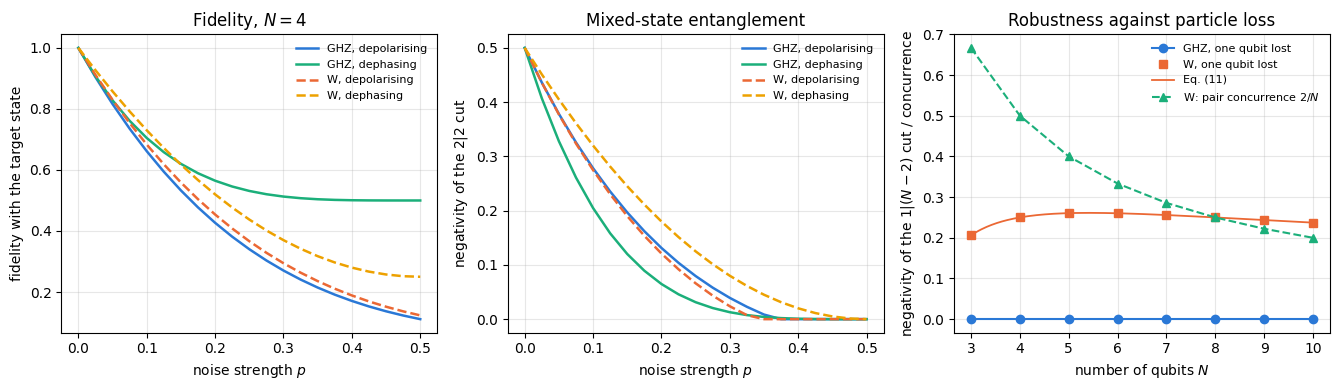

W survivors, 1|(N-2) negativity:  N=3: 0.2060  N=4: 0.2500  N=5: 0.2606  N=6: 0.2603  N=7: 0.2559  N=8: 0.2500  N=9: 0.2436  N=10: 0.2372
max |numerical - Eq. (11)| over N = 3..10: 1.39e-15


In [24]:
# ==============================================================================
# FIGURE: GHZ vs W under noise and under loss
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))
for k, (sname, ls) in enumerate((("GHZ", "-"), ("W", "--"))):
    axes[0].plot(P_CMP, cmp_data[(sname, "depolarising")][0], ls, color=PALETTE[k], lw=1.8,
                 label=f"{sname}, depolarising")
    axes[0].plot(P_CMP, cmp_data[(sname, "dephasing")][0], ls, color=PALETTE[k + 2], lw=1.8,
                 label=f"{sname}, dephasing")
axes[0].set_xlabel("noise strength $p$"); axes[0].set_ylabel("fidelity with the target state")
axes[0].set_title(f"Fidelity, $N={N_CMP}$"); axes[0].legend(fontsize=8)

for k, (sname, ls) in enumerate((("GHZ", "-"), ("W", "--"))):
    axes[1].plot(P_CMP, cmp_data[(sname, "depolarising")][1], ls, color=PALETTE[k], lw=1.8,
                 label=f"{sname}, depolarising")
    axes[1].plot(P_CMP, cmp_data[(sname, "dephasing")][1], ls, color=PALETTE[k + 2], lw=1.8,
                 label=f"{sname}, dephasing")
axes[1].set_xlabel("noise strength $p$"); axes[1].set_ylabel(r"negativity of the $2\vert2$ cut")
axes[1].set_title("Mixed-state entanglement"); axes[1].legend(fontsize=8)

Ns_loss = np.arange(3, 11)
gh, ww, cw = [], [], []
for N in Ns_loss:
    g_rest = dm_tensor(rdm(ghz_state(N), list(range(1, N))), N - 1)
    w_rest = dm_tensor(rdm(w_state(N), list(range(1, N))), N - 1)
    gh.append(neg_cut(g_rest, [0]))
    ww.append(neg_cut(w_rest, [0]))
    cw.append(concurrence(rdm(w_state(N), [0, 1])))
eq11 = (np.sqrt(4 * Ns_loss - 7) - 1) / (2 * Ns_loss)
Nfine = np.linspace(3, 10, 200)
axes[2].plot(Ns_loss, gh, MARKERS[0] + "-", color=PALETTE[0], ms=6, label="GHZ, one qubit lost")
axes[2].plot(Ns_loss, ww, MARKERS[1], color=PALETTE[1], ms=6, label="W, one qubit lost")
axes[2].plot(Nfine, (np.sqrt(4 * Nfine - 7) - 1) / (2 * Nfine), "-", color=PALETTE[1], lw=1.3, label="Eq. (11)")
axes[2].plot(Ns_loss, cw, MARKERS[2] + "--", color=PALETTE[2], ms=6, label=r"W: pair concurrence $2/N$")
axes[2].set_xlabel("number of qubits $N$")
axes[2].set_ylabel(r"negativity of the $1\vert(N-2)$ cut / concurrence")
axes[2].set_title("Robustness against particle loss"); axes[2].legend(fontsize=8)
fig.tight_layout(); plt.show()

print("W survivors, 1|(N-2) negativity:  " + "  ".join(f"N={N}: {v:.4f}" for N, v in zip(Ns_loss, ww)))
print(f"max |numerical - Eq. (11)| over N = 3..10: {np.max(np.abs(np.array(ww) - eq11)):.2e}")
assert np.max(np.abs(np.array(ww) - eq11)) < 1e-9 and max(gh) < 1e-9

Neither state is better in every respect.

Under **depolarising** noise the two curves nearly coincide at $N=4$. The W state keeps a slightly *higher fidelity* with its own
target. The reason is visible in the printed Pauli weight distributions: the fidelity under a local depolarising channel is
$F=\sum_w\lambda^wD(w)$, and $56\%$ of the GHZ weight sits on strings of the maximal weight $4$, which are damped by $\lambda^4$,
against $25\%$ for W (mean weights $3.00$ and $2.75$). The GHZ state, on the other hand, keeps a slightly *higher negativity*
across the $2\vert2$ cut and stays entangled to a slightly larger $p$; the printed thresholds differ by one grid point. Fidelity
and entanglement measure different things, and they can rank two states in opposite orders.

Under **dephasing** the negativity ranking is unambiguous: W keeps more entanglement at every $p$. Dephasing attacks exactly the
one coherence the GHZ state consists of, and that coherence connects two basis states differing on all $N$ qubits, so it decays
as $(1-2p)^N$. The W state's coherences connect basis states differing on only **two** qubits, so they decay as $(1-2p)^2$
regardless of $N$; the checkpoint confirms both laws for the $2\vert2$ negativity. The fidelities behave differently: they cross at
$p=(1-2^{-1/2})/2=0.146$, beyond which the GHZ fidelity is the larger one, because dephasing leaves the GHZ populations untouched
and $F_{\rm GHZ}$ cannot fall below $1/2$, while $F_W$ falls to $1/N$. A large fidelity is therefore no measure of how much
entanglement is left.

Right panel: the loss picture for the fixed cut $1\vert(N-2)$ of the survivors. GHZ's negativity after losing one qubit is
identically zero for every $N$, as Section 7 proved. The W state's survivors stay entangled, with the negativity of Eq. (11):
it rises from $0.206$ to $0.261$ at $N=5,6$ and then decreases slowly, as $1/\sqrt N$ for large $N$, while the pairwise
concurrence $2/N$ falls faster.

> **Physics insight.** There is no "best" multipartite entangled state. GHZ maximises the *global* correlation and the metrological
> phase gain, at the cost of being annihilated by a single loss. W spreads a weaker correlation over all pairs and survives loss.
> Which one you want depends on what breaks first in your laboratory.

## 17. Performance: when to pay $4^N$ and when to pay $M\cdot2^N$

The choice between the density tensor and trajectories is a memory/statistics trade-off:

| | density tensor | $M$ trajectories |
|---|---|---|
| memory | $O(4^N)$ | $O(M\,2^N)$ (or $O(2^N)$ one at a time) |
| cost of one local channel | $O(4^N)$ | $O(M\,2^N)$ |
| result | exact | statistical, error $\propto M^{-1/2}$ |
| nonlinear quantities | direct | need $\bar\rho$, i.e. $O(4^N)$ again |

In memory, trajectories win as soon as $M\ll2^N$ — and they win *absolutely* once $4^N$ no longer fits at all. In *time* the
verdict is less obvious, so we measure both on this machine.

In [25]:
# ==============================================================================
# BENCHMARK: density tensor vs trajectories, per noise-strength evaluation
# ==============================================================================
def timed(fn, *args, repeats=5):
    """(first call incl. compilation, best of `repeats` further calls) in seconds."""
    t0 = time.perf_counter(); jax.block_until_ready(fn(*args)); first = time.perf_counter() - t0
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter(); jax.block_until_ready(fn(*args)); best = min(best, time.perf_counter() - t0)
    return first, best


M_BENCH = 512
print(f"{'N':>3s} {'DM memory':>11s} {'DM time [ms]':>13s} {'traj memory':>12s} "
      f"{'MCWF time [ms]':>15s} {'M':>6s} {'t(DM)/t(MCWF)':>14s}")
bench_rows = []
for N in (4, 6, 8, 10, 12):
    kr = kraus_depolarizing(0.1)
    mem_dm = 16 * 4 ** N / 1024 ** 2
    mem_tr = 16 * M_BENCH * 2 ** N / 1024 ** 2
    t_dm = None
    if N <= 10:                                     # 4^12 x 16 B = 256 MB of intermediates: skip it here
        t_dm = timed(jax.jit(partial(noisy_ghz_dm, N)), kr)[1]
    t_tr = timed(jax.jit(partial(traj_batch, N=N)), jax.random.split(jax.random.PRNGKey(0), M_BENCH), kr)[1]
    bench_rows.append((N, mem_dm, t_dm, mem_tr, t_tr))
    print(f"{N:3d} {mem_dm:8.2f} MB " + (f"{t_dm * 1e3:13.2f}" if t_dm else f"{'(skipped)':>13s}") +
          f" {mem_tr:9.2f} MB {t_tr * 1e3:15.2f} {M_BENCH:6d} "
          + (f"{t_dm / t_tr:14.2f}" if t_dm else f"{'--':>14s}"))

g_dm = (bench_rows[3][2] / bench_rows[2][2]) ** 0.5        # measured growth of the DM time per added qubit
g_tr = (bench_rows[4][4] / bench_rows[3][4]) ** 0.5        # ... and of the MCWF batch time
print(f"\nmeasured growth per added qubit:  density tensor x{g_dm:.1f}   "
      f"MCWF batch x{g_tr:.1f}   (asymptotic expectation: x4 and x2)")
print(f"extrapolating the density tensor from N=10: at N=14 it would need {16 * 4 ** 14 / 1024 ** 3:.1f} GB and "
      f"roughly {bench_rows[3][2] * g_dm ** 8 / 3600:.1f} h per evaluation with the measured factor "
      f"({bench_rows[3][2] * 4 ** 8 / 3600:.1f} h with the asymptotic factor 4).")
print(f"extrapolating the trajectories from N=12: a batch of {M_BENCH} at N=14 would take roughly "
      f"{bench_rows[4][4] * g_tr ** 2:.1f} s and {16 * M_BENCH * 2 ** 14 / 1024 ** 2:.0f} MB.")
print(f"the two routes cross at N ~ {np.log(bench_rows[3][4] / bench_rows[3][2]) / np.log(g_dm / g_tr) + 10:.1f} "
      f"for M = {M_BENCH} trajectories, on the basis of the two measured growth factors.")

  N   DM memory  DM time [ms]  traj memory  MCWF time [ms]      M  t(DM)/t(MCWF)


  4     0.00 MB          0.02      0.12 MB            1.42    512           0.01


  6     0.06 MB          0.17      0.50 MB            3.74    512           0.04


  8     1.00 MB          1.69      2.00 MB           13.63    512           0.12


 10    16.00 MB         33.10      8.00 MB           75.00    512           0.44


 12   256.00 MB     (skipped)     32.00 MB          393.42    512             --

measured growth per added qubit:  density tensor x4.4   MCWF batch x2.3   (asymptotic expectation: x4 and x2)
extrapolating the density tensor from N=10: at N=14 it would need 4.0 GB and roughly 1.3 h per evaluation with the measured factor (0.6 h with the asymptotic factor 4).
extrapolating the trajectories from N=12: a batch of 512 at N=14 would take roughly 2.1 s and 128 MB.
the two routes cross at N ~ 11.2 for M = 512 trajectories, on the basis of the two measured growth factors.


The table contradicts the naive expectation: on this machine the exact density tensor is **faster** than $512$ trajectories at
every size we measured, and the ratio column stays below $1$ throughout. The reason is that the trajectory method is primarily a
**memory** optimisation: one exact evaluation replaces $M$ stochastic ones, so as long as $4^N$ fits, the exact route wins on
time *and* returns an answer with no error bar at all.

What changes the verdict is the growth rate. The density tensor costs $O(4^N)$ in time *and* memory, and the measured factor per
added qubit is at least the asymptotic $4$ (above it in our builds, from cache effects and machine load). The trajectory batch costs
$O(M\,2^N)$ and grows by about $2$ per qubit at fixed $M$. From $N=8$ on the ratio column climbs steeply, and the crossover
extrapolated from the two measured growth factors is printed above, between $N=10$ and $N=12$ in our builds. At $N=14$ the
exact route needs $4$ GB per copy of the density tensor and, extrapolated with the asymptotic factor $4$, between half an hour
and an hour per evaluation in our builds, while a batch of $512$ trajectories extrapolates to a few seconds and $128$ MB. The absolute timings depend on what
else the machine is doing (several builds may run concurrently here, and a single slow $N=10$ timing inflates the measured
growth factor and with it the first extrapolation), so the *ratios* and the asymptotic growth are the reproducible part of
the table. At $N=16$ the density tensor would need $64$ GB per copy, while $512$ trajectories need $512$ MB, or $1$ MB each if
they are run one at a time.

> **Numerical practice.** The crossover also depends on the accuracy you need. A statistical error $\varepsilon$ costs
> $M\sim\sigma^2/\varepsilon^2$ trajectories, so demanding one more digit costs a factor of $100$ in time. If you need $10^{-8}$
> on a small system, use the density tensor; if you need $10^{-2}$ on a system that does not fit, use trajectories. And if you
> need a *nonlinear* quantity on a large system, neither method provides it; estimating nonlinear functionals of large mixed
> states is a research problem of its own.

## 18. Key takeaways

* **The GHZ state is two amplitudes and one coherence.** Every bipartition carries exactly one bit of entanglement entropy; the
  whole resource is the single matrix element $\rho_{\bar0\bar1}$, which is why everything about it is fragile.
* **Preparation.** $1$ Hadamard and $N-1$ $\mathrm{CNOT}$s, either as a depth-$(N-1)$ cascade or as a depth-$\lceil\log_2N\rceil$
  tree; no circuit of two-qubit gates uses fewer than $N-1$, while the depth can be reduced at the price of long-range
  connectivity. Both circuits reproduced the
  reference tensor exactly, to the last bit of double precision.
* **Certification is cheap.** $N$ stabiliser generators ($Z_qZ_{q+1}$ and $X^{\otimes N}$) determine the state uniquely; two
  measurement settings (populations and a parity fringe) give the fidelity through Eq. (4); and $F>1/2$ *proves* genuine
  $N$-partite entanglement by the Cauchy–Schwarz argument of Eq. (5). The same stabilisers produce the Greenberger–Horne–Zeilinger
  all-or-nothing contradiction with local realism — verified here as four exact signs.
* **Perfect correlation without pairwise entanglement.** Every pair has $\langle Z_iZ_j\rangle=1$, yet for $N\ge3$ every two-qubit reduced
  state is the *separable* classical mixture of Eq. (1), with zero negativity and zero concurrence, and losing one qubit leaves a
  state with zero entanglement across **every** cut.
* **Parity oscillations measure the $N$-body coherence.** A collective $R_z(\varphi)$ makes $\langle X^{\otimes N}\rangle$
  oscillate as $\cos(N\varphi)$ — $N$ fringes per $2\pi$, verified to $10^{-9}$ for $N=2,3,4,6$ — and the fringe *amplitude* is
  $2\vert\rho_{\bar0\bar1}\vert$. A classical mixture gives a flat line.
* **Decoherence has closed forms.** Dephasing: coherence $(1-2p)^N$, $F=\tfrac12+\tfrac12(1-2p)^N$, $\langle Z_iZ_j\rangle=1$
  untouched. Depolarising: everything multiplied by $\lambda^{w}$ with $\lambda=1-\tfrac{4p}{3}$, giving Eq. (7) for the fidelity.
  Amplitude damping: Eqs. (8)–(9), with a fidelity that returns to $1/2$ at complete damping. All checked against exact Kraus
  evolution to $10^{-9}$ for $N\le6$, and the depolarising case against trajectories up to $N=12$, where a control with the
  Bloch factor $1-p$ is rejected.
* **Fragility scales like $1/N$.** The dephasing half-point is $p_{1/2}=(1-2^{-1/N})/2\simeq\ln2/(2N)$; the depolarising and
  amplitude-damping witness thresholds tend to $3\ln\varphi/(2N)=0.7218/N$ and $2\ln(1+\sqrt2)/N=1.7627/N$. Power laws
  fitted at finite $N$ come out shallower than $-1$: $-0.944$ for $p_{1/2}$ over $N=2,\dots,20$, which the $O(1/N)$ correction
  to the expansion explains ($-1.000$ over $N=10^2,\dots,10^4$), and $-0.966$ for the depolarising threshold over
  $N=6,\dots,20$. At fixed per-qubit noise the coherence decays *exponentially* in $N$, while the gate count grows only
  linearly; the decay is the real obstacle to large cat states. The $1/N$ law
  assumes independent environments; a common-mode field gives the $N^2$ superdecoherence measured in ion traps.
* **Trajectories versus density tensors.** MCWF trades $4^N$ memory for $M\cdot2^N$ and a $1/\sqrt M$ statistical error; our
  measured RMS error followed a fitted power law close to $M^{-1/2}$ and the reported error bars were calibrated to about ten per
  cent; for Pauli channels every trajectory has $F_m\in\{0,1\}$, so the error bars are binomial and were checked against
  $\sqrt{F(1-F)/M}$. It is a *memory* optimisation: the measured timings show the exact density tensor is the faster route up to
  $N=10$, and the reason to abandon it is its $\times4$ growth per qubit. Only **linear** functionals may be averaged over
  trajectories: averaging the purity of each trajectory, which is pure, gives the constant $1$, a mistake the figure in
  Section 13 makes on purpose.
* **The W state as the alternative.** The W state has pairwise concurrence $2/N$ where GHZ has $0$, and its survivors stay
  entangled after the loss of a qubit, with negativity $(\sqrt{4N-7}-1)/(2N)$ across the $1\vert(N-2)$ cut (Eq. (11): $0.21$ to
  $0.26$ for $N=3,\dots,8$, decaying as $1/\sqrt N$ beyond), where GHZ keeps none. Under dephasing its entanglement is far more
  robust, because its coherences involve two qubits and decay as $(1-2p)^2$ instead of $(1-2p)^N$, although its fidelity drops
  below that of GHZ for $p>0.146$; under depolarising noise the two are nearly equivalent at $N=4$, and the ranking depends on
  whether one asks about fidelity or about negativity. The two are inequivalent resources, and the right choice depends on the dominant error in the hardware.

## 19. Exercises

1. ★ **Count the stabiliser group.** The $N$ generators of Section 5 generate a group of $2^N$ Pauli strings. Write code that
   enumerates it for $N=4$ *as matrices* (multiply the generators; do not guess the letters, because
   $X^{\otimes4}Z_0Z_1=-YYXX$ carries a minus sign), verify that $2^{-N}\sum_{P\in\mathcal S}P$ equals
   $\vert\mathrm{GHZ}\rangle\langle\mathrm{GHZ}\vert$, and check the weight distribution used in the derivation of Eq. (7):
   $2^{N-1}$ strings of even $Z$-weight and $2^{N-1}$ strings of weight exactly $N$.
2. ★ **Fringe fitting.** Add shot noise to the parity signal: sample $\langle X^{\otimes N}\rangle$ from $M$ measurements in the
   rotated basis for each of $16$ values of $\varphi$ spread over **one** fringe, $\varphi\in[0,2\pi/N)$ (sampling over the full
   $[0,2\pi)$ with only $16$ points aliases the $N$ fringes for $N\ge4$), fit $A\cos(N\varphi-\phi_0)$, and determine how many
   shots are needed to resolve $A=0.1$ with a relative error of $10\%$. Compare with the $N$-dependence of Section 15.
   *Hint:* the parity is a $\pm1$ variable, so one shot has variance $1-\langle X^{\otimes N}\rangle^2\le1$.
3. ★★ **A different collective rotation (extend the code).** Replace $R_z(\varphi)$ by $R_z(\varphi)$ applied to only $k$ of the
   $N$ qubits. Predict the fringe frequency, verify it, and explain what this means for the *calibration* of a GHZ
   interferometer when one qubit is miscalibrated.
4. ★★ **Noise during preparation (physics).** Apply depolarising noise of strength $p$ to **every** qubit after every
   $\mathrm{CNOT}$ layer (the idling qubits decohere too — that is the point), for the cascade and for the tree. The cascade
   then has $N-1$ noise layers, the tree $\lceil\log_2N\rceil$. Compute the final fidelity for $N=6$ and $N=8$ as a function of
   $p$ and show quantitatively how much the log-depth circuit gains. Compare the ratio of the two infidelities at small $p$ with
   the ratio of the layer counts, explain why the ratio falls as $p$ grows, and find, for $N=8$, the range of $p$ in which the
   tree's infidelity is less than half that of the cascade. Is there such a range for $N=6$?
5. ★★ **Error bars on the witness.** For $N=8$ and depolarising $p=0.05$, estimate $F$ from $M$ trajectories and determine the
   smallest $M$ for which the statement "$F>1/2$" holds at the $3\sigma$ level. Repeat for $N=12$ and comment on the scaling.
   Then try $p=0.1$ and explain what you find: Eq. (7) gives $F=0.447$ at $N=8$, below the threshold, so *no* number of
   trajectories can make the witness fire — the state really is past the point where this certificate works.
6. ★★ **Dicke states (extend the code).** Repeat Section 16 for the Dicke state $\vert D_N^{N/2}\rangle$ (half the qubits
   excited), using the engine's `dicke_state`. Compute its pairwise concurrence, its behaviour under the loss of one qubit and
   its fidelity under dephasing, and compare each of the three with the GHZ and the W state of the same $N$.
7. ★★★ **Coherence half-life in time (physics).** Model dephasing as a continuous process, $p(t)=\tfrac12(1-e^{-t/T_2})$, and show
   that the GHZ coherence decays as $e^{-Nt/T_2}$: the $N$-qubit coherence time is $T_2/N$. Simulate it with trajectories for
   $N=2,\dots,12$, extract $T_2^{(N)}$ from an exponential fit, and reproduce the $1/N$ law. Then repeat with a *common* random
   phase $\phi$, drawn once per shot from a Gaussian of variance $2t/T_2$ (chosen so that a single qubit again loses its
   coherence as $e^{-t/T_2}$) and applied as $R_z(\phi)$ to all $N$ qubits, and show that the decay rate now grows as $N^2$:
   the superdecoherence that Monz and co-workers measured on up to eight ions.
8. ★★★ **Decoherence-free encoding (extend the code).** Under *collective* dephasing — the same $Z$ rotation applied to all
   qubits — the state $(\vert01\rangle-\vert10\rangle)/\sqrt2$ is untouched. Build the four-qubit state
   $\vert\Psi^-\rangle\otimes\vert\Psi^-\rangle$ and an encoded GHZ-like superposition inside the decoherence-free subspace,
   and show numerically that the collective channel leaves them invariant while the local channel of Section 10 does not. What
   does this cost in terms of qubits per logical qubit?

## References

* D. M. Greenberger, M. A. Horne and A. Zeilinger, *Going beyond Bell's theorem*, in *Bell's Theorem, Quantum Theory and
  Conceptions of the Universe*, ed. M. Kafatos (Kluwer, Dordrecht, 1989), pp. 69–72 — the state and the all-or-nothing argument, for four particles.
* N. D. Mermin, *Extreme quantum entanglement in a superposition of macroscopically distinct states*, Phys. Rev. Lett. **65**,
  1838 (1990) — a Bell inequality for $N$ spins violated by an amount that grows exponentially with $N$; the many-body
  version pointed to at the end of Section 5.2.
* N. D. Mermin, *What's wrong with these elements of reality?*, Physics Today **43**(6), 9 (1990) — the three-particle form of
  the GHZ contradiction, with $x$ and $y$ spin measurements, used in Section 5.2.
* W. Dür, G. Vidal and J. I. Cirac, *Three qubits can be entangled in two inequivalent ways*, Phys. Rev. A **62**, 062314 (2000) —
  the GHZ/W classification of Section 16.
* C. A. Sackett, D. Kielpinski, B. E. King, C. Langer, V. Meyer, C. J. Myatt, M. Rowe, Q. A. Turchette, W. M. Itano,
  D. J. Wineland and C. Monroe, *Experimental entanglement of four particles*, Nature **404**, 256 (2000) — parity oscillations
  and the populations-plus-parity fidelity estimate of Eq. (4).
* D. Leibfried, E. Knill, S. Seidelin, J. Britton, R. B. Blakestad, J. Chiaverini, D. B. Hume, W. M. Itano, J. D. Jost,
  C. Langer, R. Ozeri, R. Reichle and D. J. Wineland, *Creation of a six-atom "Schrödinger cat" state*, Nature **438**, 639
  (2005).
* T. Monz, P. Schindler, J. T. Barreiro, M. Chwalla, D. Nigg, W. A. Coish, M. Harlander, W. Hänsel, M. Hennrich and R. Blatt,
  *14-qubit entanglement: creation and coherence*, Phys. Rev. Lett. **106**, 130506 (2011) — GHZ states of up to $14$ ions, and
  the coherence decay measured on up to $8$ ions, which grows as $N^2$ because the magnetic-field noise is correlated across
  the crystal (the independent-environment case of Section 15 gives $N$).
* O. Gühne and G. Tóth, *Entanglement detection*, Physics Reports **474**, 1 (2009) — entanglement witnesses, including the
  projector witness of Eq. (5).
* M. Bourennane, M. Eibl, C. Kurtsiefer, S. Gaertner, H. Weinfurter, O. Gühne, P. Hyllus, D. Bruß, M. Lewenstein and A. Sanpera,
  *Experimental detection of multipartite entanglement using witness operators*, Phys. Rev. Lett. **92**, 087902 (2004).
* G. Vidal and R. F. Werner, *Computable measure of entanglement*, Phys. Rev. A **65**, 032314 (2002) — negativity.
* W. K. Wootters, *Entanglement of formation of an arbitrary state of two qubits*, Phys. Rev. Lett. **80**, 2245 (1998) —
  concurrence.
* K. Mølmer and A. Sørensen, *Multiparticle entanglement of hot trapped ions*, Phys. Rev. Lett. **82**, 1835 (1999) — the
  interaction used to make GHZ states in ion traps in a single step.
* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information* (Cambridge University Press, 2000) —
  Chapters 2, 8 and 10 for density matrices, channels and the stabiliser formalism.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/